# MRI Recon Tutorial

## 1. Phython Environment

In [8]:
%pip install numpy matplotlib h5py scipy sigpy pymapvbvd torch twixtools pypulseq

Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy
import sigpy as sp
import sigpy.mri as mr
import mapvbvd
import torch
import torch.nn as nn
import torch.nn.functional as F
import twixtools
import pypulseq as pp

print("Environment is ready.")
print("NumPy:", np.__version__)
print("h5py:", h5py.__version__)
print("SciPy:", scipy.__version__)
print("SigPy:", sp.__version__)
print("PyTorch:", torch.__version__)
print("mapVBVD imported successfully.")

Environment is ready.
NumPy: 2.2.6
h5py: 3.14.0
SciPy: 1.15.3
SigPy: 0.1.27
PyTorch: 2.12.0
mapVBVD imported successfully.


### 1.1 Compute Device Selection and Verification

On Apple silicon, PyTorch can run on the GPU through the Metal Performance Shaders (MPS) backend.
The device is selected in the order MPS, CUDA, and finally CPU.

The MPS backend does not implement every complex-valued operation used by the MRI forward model.
The helper below therefore runs a small complex FFT and coil-combination test on the candidate device
and falls back to the CPU if any operation is unsupported.

`verify_device` reports where the tensors actually live and times a matrix product on both the CPU and
the selected device, so the notebook can confirm that the GPU is really being used.

In [10]:
import os
import time

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")


# Test the operations the MRI forward model needs on a candidate device

def device_supports_pipeline(candidate):
    try:
        probe = torch.randn(
            2, 8, 8,
            dtype=torch.complex64,
            device=candidate
        )

        spectrum = torch.fft.fftshift(
            torch.fft.fft2(
                torch.fft.ifftshift(probe, dim=(-2, -1)),
                dim=(-2, -1),
                norm="ortho"
            ),
            dim=(-2, -1)
        )

        image = torch.fft.ifft2(spectrum, dim=(-2, -1), norm="ortho")

        combined = torch.sum(torch.conj(probe) * image, dim=0)
        magnitude = torch.abs(combined).sum()

        real_part = torch.complex(
            magnitude.real if magnitude.is_complex() else magnitude,
            torch.zeros_like(magnitude.real if magnitude.is_complex() else magnitude)
        )

        _ = real_part.cpu()

        return True

    except Exception as error:
        print("사용 불가:", candidate, "->", type(error).__name__, error)
        return False


# Choose MPS, then CUDA, then CPU

def select_device(verbose=True):
    if verbose:
        print("PyTorch 버전:", torch.__version__)
        print("MPS 빌드 여부:", torch.backends.mps.is_built())
        print("MPS 사용 가능:", torch.backends.mps.is_available())
        print("CUDA 사용 가능:", torch.cuda.is_available())

    if torch.backends.mps.is_available():
        candidate = torch.device("mps")

        if device_supports_pipeline(candidate):
            if verbose:
                print("선택된 장치: MPS (Apple GPU)")
            return candidate

        if verbose:
            print("MPS가 복소수 연산을 지원하지 않아 CPU로 되돌립니다.")

    if torch.cuda.is_available():
        candidate = torch.device("cuda")

        if device_supports_pipeline(candidate):
            if verbose:
                print("선택된 장치: CUDA")
            return candidate

    if verbose:
        print("선택된 장치: CPU")

    return torch.device("cpu")


# Confirm that tensors are really placed on the selected device

def verify_device(selected_device, matrix_size=2048, n_repeats=3):
    probe = torch.zeros(4, 4, device=selected_device)

    print("요청한 장치:", selected_device)
    print("실제 텐서 장치:", probe.device)
    print("GPU 사용 여부:", probe.device.type in ("mps", "cuda"))

    def timed_matmul(target):
        a = torch.randn(matrix_size, matrix_size, device=target)
        b = torch.randn(matrix_size, matrix_size, device=target)

        if target.type == "mps":
            torch.mps.synchronize()
        elif target.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        for _ in range(n_repeats):
            c = a @ b

        if target.type == "mps":
            torch.mps.synchronize()
        elif target.type == "cuda":
            torch.cuda.synchronize()

        return (time.time() - start) / n_repeats

    cpu_time = timed_matmul(torch.device("cpu"))
    print(f"CPU 행렬곱 평균 시간: {cpu_time * 1000:.1f} ms")

    if selected_device.type != "cpu":
        device_time = timed_matmul(selected_device)

        print(
            f"{selected_device.type.upper()} 행렬곱 평균 시간: "
            f"{device_time * 1000:.1f} ms"
        )

        print(f"속도 비율: {cpu_time / (device_time + 1e-12):.2f}배")

    return probe.device


# Run the selection once so the device is available to later cells

device = select_device()

verify_device(device)

PyTorch 버전: 2.12.0
MPS 빌드 여부: True
MPS 사용 가능: True
CUDA 사용 가능: False
선택된 장치: MPS (Apple GPU)
요청한 장치: mps
실제 텐서 장치: mps:0
GPU 사용 여부: True
CPU 행렬곱 평균 시간: 7.1 ms
MPS 행렬곱 평균 시간: 6.5 ms
속도 비율: 1.09배


device(type='mps', index=0)

## 2. Load the MRI k-space data

The scanner stores the acquired MRI measurements in a Siemens raw data file.

The data contain measurements from multiple receiver coils. After loading, we arrange the k-space array as:

`[coil, ky, kx]`

where:

- `coil` is the receiver-coil channel
- `ky` is the phase-encoding direction
- `kx` is the readout direction

The scanner samples twice as many points along the readout direction, so we remove this readout oversampling during loading.

In [11]:
# Load Siemens raw k-space data
data_path = "/Users/hong-igdaebaiohelseu/Desktop/mri_recon/hackathon_data/meas_MID00185_FID32269_pulseq_gre_R1_yunseo.dat"
twix_obj = mapvbvd.mapVBVD(data_path)
twix = twix_obj[-1] if isinstance(twix_obj, list) else twix_obj

# Remove readout oversampling
twix.image.flagRemoveOS = False
img_raw = np.asarray(twix.image[""]).squeeze()

# Convert from [kx, coil, ky] to [coil, ky, kx]
kspace = np.transpose(img_raw, (1, 2, 0)).astype(np.complex64)
kspace_full = kspace.copy()

print("K-space shape [coil, ky, kx]:", kspace.shape)

pymapVBVD version 0.6.1
Software version: VD


Scan 1/2, read all mdhs:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

Scan 2/2, read all mdhs:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

read data:   0%|          | 0/256 [00:00<?, ?it/s]

K-space shape [coil, ky, kx]: (32, 256, 256)


## 3. Fully Sampled IFFT Reconstruction

For coil $c$, the MRI signal model is

$$
y_c = F(C_c x) + n_c
$$

where:

- $x$ is the unknown true image
- $C_c$ is the sensitivity of coil $c$
- $F$ is the 2D Fourier transform
- $y_c$ is the measured k-space for coil $c$
- $n_c$ is measurement noise

Because the k-space is fully sampled, we apply a 2D inverse fast Fourier transform to each coil:

$$
\hat{x}_c = F^{-1}y_c \approx C_c x
$$

where $\hat{x}_c$ is the reconstructed image from coil $c$.

We then combine the coil images using root-sum-of-squares:

$$
\hat{x}_{\mathrm{RSS}} = \sqrt{\sum_c |\hat{x}_c|^2}
$$

Reconstructed image shape: (256, 256)


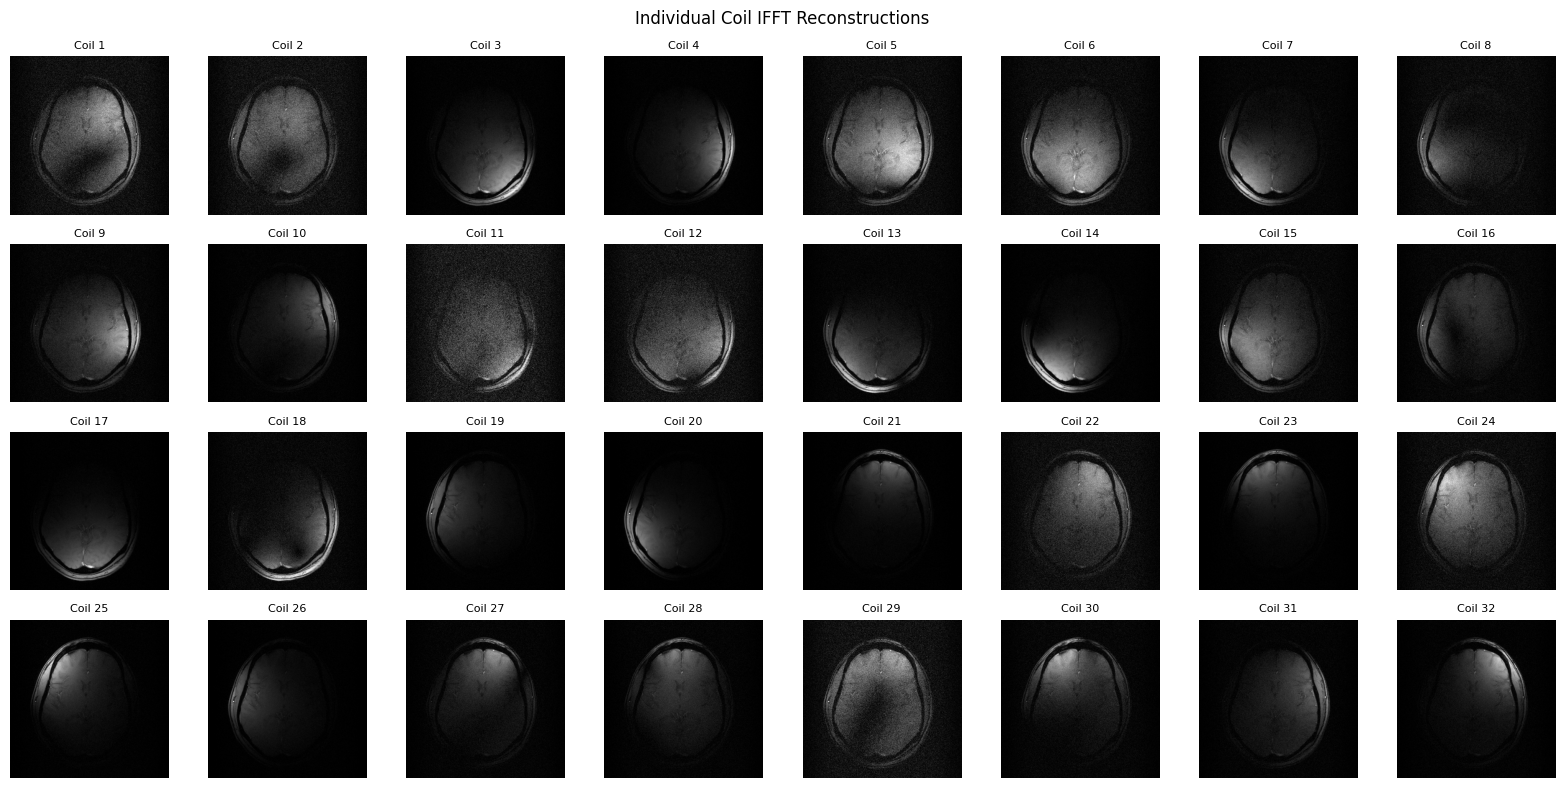

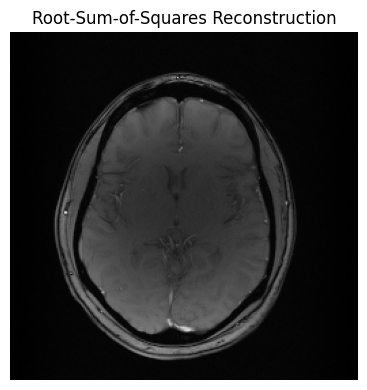

In [12]:
# Apply a centered 2D IFFT to each coil
x_hat_coils = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(kspace, axes=(-2, -1)),
        axes=(-2, -1)
    ),
    axes=(-2, -1)
)

# Combine the coil images using root-sum-of-squares
x_hat_rss = np.sqrt(np.sum(np.abs(x_hat_coils) ** 2, axis=0))

print("Reconstructed image shape:", x_hat_rss.shape)

# Display all individual coil images
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for coil, ax in enumerate(axes.flat):
    ax.imshow(np.abs(x_hat_coils[coil]), cmap="gray")
    ax.set_title(f"Coil {coil + 1}", fontsize=8)
    ax.axis("off")

fig.suptitle("Individual Coil IFFT Reconstructions")
plt.tight_layout()
plt.show()

# Display the RSS reconstruction separately
plt.figure(figsize=(8, 4))
plt.imshow(x_hat_rss, cmap="gray")
plt.title("Root-Sum-of-Squares Reconstruction")
plt.axis("off")
plt.tight_layout()
plt.show()

### 3.1 Brain Mask and Evaluation Metrics

Reconstruction errors measured over the whole field of view are dominated by the air surrounding the head,
where the true signal is zero and only noise remains.
A binary brain mask is therefore estimated from the fully sampled reconstruction, and every metric below is
evaluated inside that mask only.

Three metrics are used to compare reconstructions:

- relative $\ell_2$ error, reported as a percentage
- peak signal-to-noise ratio (PSNR), reported in decibels
- structural similarity index (SSIM), between 0 and 1

The intensity scale of each reconstruction is matched to the reference inside the mask before the metrics are computed.

영상 전체 픽셀 수: 65536
뇌 영역 픽셀 수: 27887
뇌 영역 비율: 42.6%
Reference dtype: float64
Reference min/max: 1.5430881461497847e-08 2.1919465780229075e-06


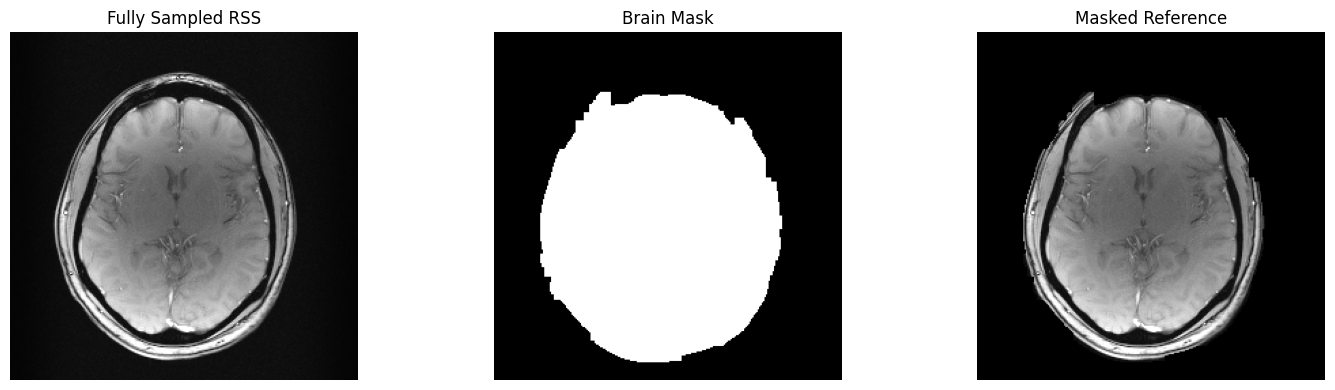

In [13]:
from scipy import ndimage


# ============================================================
# [수정됨] Brain mask and numerically stable evaluation metrics
# ============================================================


# Otsu threshold computed from the image histogram
def otsu_threshold(values, n_bins=256):

    values = np.asarray(
        values,
        dtype=np.float64
    )

    histogram, edges = np.histogram(
        values,
        bins=n_bins
    )

    centers = (
        edges[:-1] + edges[1:]
    ) / 2

    weight_background = np.cumsum(
        histogram,
        dtype=np.float64
    )

    weight_foreground = (
        weight_background[-1]
        - weight_background
    )

    valid = (
        (weight_background > 0)
        & (weight_foreground > 0)
    )

    cumulative_mean = np.cumsum(
        histogram * centers,
        dtype=np.float64
    )

    total_mean = cumulative_mean[-1]

    mean_background = np.where(
        weight_background > 0,
        cumulative_mean
        / np.maximum(weight_background, 1),
        0
    )

    mean_foreground = np.where(
        weight_foreground > 0,
        (
            total_mean
            - cumulative_mean
        )
        / np.maximum(weight_foreground, 1),
        0
    )

    variance = (
        weight_background
        * weight_foreground
        * (
            mean_background
            - mean_foreground
        ) ** 2
    )

    variance[~valid] = 0

    return float(
        centers[np.argmax(variance)]
    )


# Estimate a binary brain mask from a magnitude image
def build_brain_mask(
    image,
    floor_fraction=0.05
):

    image = np.asarray(
        np.abs(image),
        dtype=np.float64
    )

    image_max = np.max(image)

    if image_max <= 0:
        raise ValueError(
            "Reference image maximum is zero. "
            "The brain mask cannot be generated."
        )

    normalized = image / image_max

    threshold = max(
        otsu_threshold(
            normalized.ravel()
        ),
        floor_fraction
    )

    mask = normalized > threshold

    mask = ndimage.binary_opening(
        mask,
        structure=np.ones(
            (3, 3),
            dtype=bool
        )
    )

    mask = ndimage.binary_closing(
        mask,
        structure=np.ones(
            (7, 7),
            dtype=bool
        )
    )

    mask = ndimage.binary_fill_holes(
        mask
    )

    labels, n_labels = ndimage.label(
        mask
    )

    if n_labels > 0:

        sizes = ndimage.sum(
            mask,
            labels,
            range(1, n_labels + 1)
        )

        largest_label = (
            np.argmax(sizes) + 1
        )

        mask = (
            labels == largest_label
        )

    mask = ndimage.binary_dilation(
        mask,
        structure=np.ones(
            (3, 3),
            dtype=bool
        ),
        iterations=2
    )

    mask = ndimage.binary_fill_holes(
        mask
    )

    return np.asarray(
        mask,
        dtype=bool
    )


# Match the global intensity scale inside the mask
def match_intensity_masked(
    image,
    reference,
    mask
):

    image = np.asarray(
        np.abs(image),
        dtype=np.float64
    )

    reference = np.asarray(
        np.abs(reference),
        dtype=np.float64
    )

    mask = np.asarray(
        mask,
        dtype=bool
    )

    if not np.any(mask):
        raise ValueError(
            "The evaluation mask is empty."
        )

    numerator = np.sum(
        reference[mask]
        * image[mask],
        dtype=np.float64
    )

    denominator = np.sum(
        image[mask]
        * image[mask],
        dtype=np.float64
    )

    if denominator <= 1e-20:
        return np.zeros_like(
            image,
            dtype=np.float64
        )

    scale = (
        numerator
        / denominator
    )

    return scale * image


# Relative L2 error inside the mask, in percent
def masked_relative_error(
    image,
    reference,
    mask
):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    reference = np.asarray(
        reference,
        dtype=np.float64
    )

    mask = np.asarray(
        mask,
        dtype=bool
    )

    difference = (
        image[mask]
        - reference[mask]
    )

    reference_norm = np.linalg.norm(
        reference[mask]
    )

    return float(
        100
        * np.linalg.norm(difference)
        / (reference_norm + 1e-12)
    )


# Peak signal-to-noise ratio inside the mask, in decibels
def masked_psnr(
    image,
    reference,
    mask
):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    reference = np.asarray(
        reference,
        dtype=np.float64
    )

    mask = np.asarray(
        mask,
        dtype=bool
    )

    # [수정됨] Normalize before squaring to prevent
    # overflow or loss of numerical precision.
    reference_peak = np.max(
        np.abs(reference[mask])
    )

    if reference_peak <= 1e-20:
        return float("nan")

    image_normalized = (
        image / reference_peak
    )

    reference_normalized = (
        reference / reference_peak
    )

    difference = (
        image_normalized[mask]
        - reference_normalized[mask]
    )

    mean_squared_error = np.mean(
        difference * difference,
        dtype=np.float64
    )

    if mean_squared_error <= 1e-20:
        return float("inf")

    return float(
        10
        * np.log10(
            1.0
            / mean_squared_error
        )
    )


# Structural similarity averaged inside the mask
def masked_ssim(
    image,
    reference,
    mask,
    sigma=1.5
):

    image = np.asarray(
        image,
        dtype=np.float64
    )

    reference = np.asarray(
        reference,
        dtype=np.float64
    )

    mask = np.asarray(
        mask,
        dtype=bool
    )

    reference_peak = np.max(
        np.abs(reference[mask])
    )

    if reference_peak <= 1e-20:
        return float("nan")

    # [수정됨] Use the same normalization
    # for the reconstruction and reference.
    image_normalized = (
        image / reference_peak
    )

    reference_normalized = (
        reference / reference_peak
    )

    # Both normalized images use a common data range of 1.
    data_range = 1.0

    c1 = (
        0.01 * data_range
    ) ** 2

    c2 = (
        0.03 * data_range
    ) ** 2

    def smooth(array):

        return ndimage.gaussian_filter(
            np.asarray(
                array,
                dtype=np.float64
            ),
            sigma=sigma,
            truncate=3.5,
            mode="reflect"
        )

    mean_x = smooth(
        image_normalized
    )

    mean_y = smooth(
        reference_normalized
    )

    # [수정됨] Multiplication occurs after conversion
    # to float64.
    second_moment_x = smooth(
        image_normalized
        * image_normalized
    )

    second_moment_y = smooth(
        reference_normalized
        * reference_normalized
    )

    cross_moment = smooth(
        image_normalized
        * reference_normalized
    )

    variance_x = (
        second_moment_x
        - mean_x * mean_x
    )

    variance_y = (
        second_moment_y
        - mean_y * mean_y
    )

    covariance = (
        cross_moment
        - mean_x * mean_y
    )

    # Remove very small negative variances caused
    # by floating-point round-off.
    variance_x = np.maximum(
        variance_x,
        0.0
    )

    variance_y = np.maximum(
        variance_y,
        0.0
    )

    numerator = (
        (
            2
            * mean_x
            * mean_y
            + c1
        )
        *
        (
            2
            * covariance
            + c2
        )
    )

    denominator = (
        (
            mean_x * mean_x
            + mean_y * mean_y
            + c1
        )
        *
        (
            variance_x
            + variance_y
            + c2
        )
    )

    ssim_map = (
        numerator
        / (
            denominator
            + 1e-12
        )
    )

    # [수정됨] Exclude mask boundaries because
    # the Gaussian SSIM window may include air pixels.
    ssim_mask = ndimage.binary_erosion(
        mask,
        structure=np.ones(
            (3, 3),
            dtype=bool
        ),
        iterations=4
    )

    if not np.any(ssim_mask):
        ssim_mask = mask

    valid_values = ssim_map[
        ssim_mask
    ]

    valid_values = valid_values[
        np.isfinite(valid_values)
    ]

    if valid_values.size == 0:
        return float("nan")

    return float(
        np.mean(valid_values)
    )


# Compute all three metrics for one reconstruction
def evaluate_reconstruction(
    image,
    reference,
    mask,
    match_scale=True
):

    image = np.asarray(
        np.abs(image),
        dtype=np.float64
    )

    reference = np.asarray(
        np.abs(reference),
        dtype=np.float64
    )

    mask = np.asarray(
        mask,
        dtype=bool
    )

    if image.shape != reference.shape:
        raise ValueError(
            "Reconstruction and reference "
            f"shapes differ: {image.shape} vs "
            f"{reference.shape}"
        )

    if mask.shape != reference.shape:
        raise ValueError(
            "Mask and reference shapes differ: "
            f"{mask.shape} vs {reference.shape}"
        )

    matched = (
        match_intensity_masked(
            image,
            reference,
            mask
        )
        if match_scale
        else image.copy()
    )

    relative_error = (
        masked_relative_error(
            matched,
            reference,
            mask
        )
    )

    psnr = masked_psnr(
        matched,
        reference,
        mask
    )

    ssim = masked_ssim(
        matched,
        reference,
        mask
    )

    return {
        "image": matched,
        "relative_error": relative_error,
        "psnr": psnr,
        "ssim": ssim
    }


# Build the brain mask from the fully sampled reconstruction
reference_image = np.asarray(
    np.abs(x_hat_rss),
    dtype=np.float64
)

brain_mask = build_brain_mask(
    reference_image
)

print(
    "영상 전체 픽셀 수:",
    brain_mask.size
)

print(
    "뇌 영역 픽셀 수:",
    int(brain_mask.sum())
)

print(
    f"뇌 영역 비율: "
    f"{100 * brain_mask.mean():.1f}%"
)

print(
    "Reference dtype:",
    reference_image.dtype
)

print(
    "Reference min/max:",
    float(reference_image.min()),
    float(reference_image.max())
)


# Display the mask and the masked reference
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

display_vmax = np.percentile(
    reference_image,
    99.5
)

axes[0].imshow(
    reference_image,
    cmap="gray",
    vmin=0,
    vmax=display_vmax
)

axes[0].set_title(
    "Fully Sampled RSS"
)

axes[1].imshow(
    brain_mask,
    cmap="gray"
)

axes[1].set_title(
    "Brain Mask"
)

axes[2].imshow(
    reference_image
    * brain_mask,
    cmap="gray",
    vmin=0,
    vmax=display_vmax
)

axes[2].set_title(
    "Masked Reference"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Retrospective Undersampling and Reference Scan

### 4.1 Undersampling and Reference Data

For coil $c$, the undersampled MRI acquisition is modeled as

$$
y_c = M F(C_c x) + n_c
$$

where:

- $x$ is the unknown image
- $C_c$ is the sensitivity of coil $c$
- $F$ is the 2D Fourier transform
- $M$ is the undersampling mask
- $y_c$ is the measured undersampled k-space
- $n_c$ is measurement noise

For acceleration factor $R=2$, the mask $M$ retains every second $k_y$ line.

SENSE also requires coil-sensitivity maps. These are estimated from a fully sampled, low-resolution reference scan:

$$
z_c = M_{\mathrm{ref}} F(C_c x) + e_c
$$

where $M_{\mathrm{ref}}$ retains a fully sampled group of central $k_y$ lines.

Because the current test file does not contain a separate reference scan, we simulate the reference data using the central fully sampled $k_y$ lines from the original acquisition.

pymapVBVD version 0.6.1
Software version: VD


Scan 1/2, read all mdhs:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

Scan 2/2, read all mdhs:   0%|          | 0.00/9.42M [00:00<?, ?B/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

Number of acquired lines: 128
Number of reference lines: 24


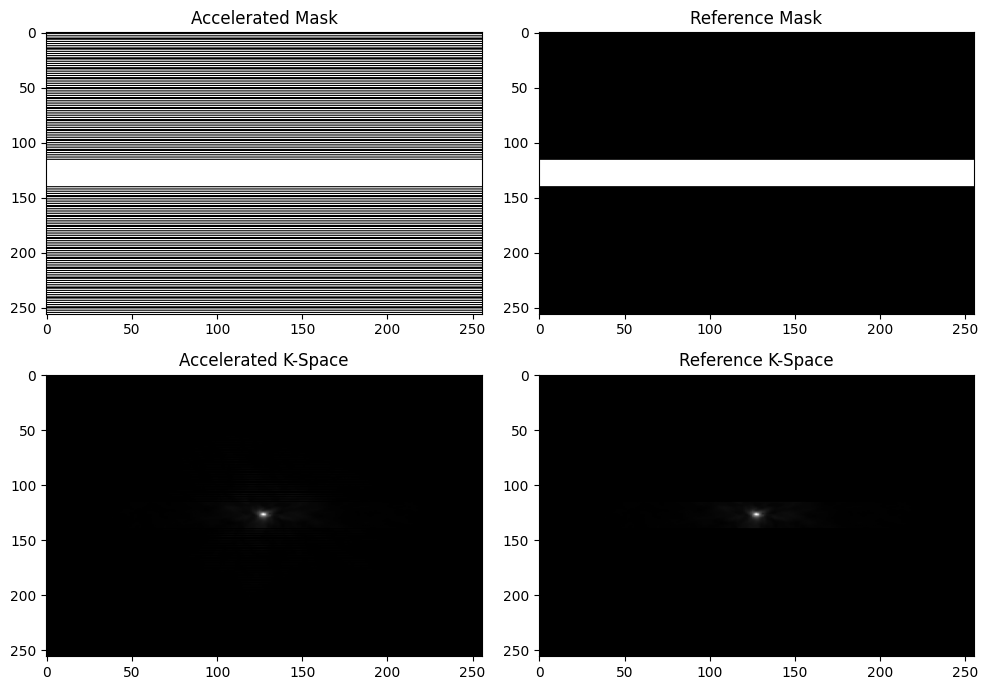

In [14]:
R = 2
ny = 256

data_path = ("/Users/hong-igdaebaiohelseu/Desktop/mri_recon/hackathon_data/meas_MID00190_FID32274_pulseq_gre_R2_uniform_yunseo.dat"
    #r"C:\Users\unayd\Partners HealthCare Dropbox"
    #r"\Unay Dorken Gallastegi\Hackathon\Test_data\hackathon_data"
    #r"\meas_MID00189_FID32273_pulseq_gre_R2_random_yunseo.dat"
)

seq_path = ("/Users/hong-igdaebaiohelseu/Desktop/mri_recon/gre_seq_files/gre_R2_uniform_v01.seq"
    #r"C:\Users\unayd\Partners HealthCare Dropbox"
    #r"\Unay Dorken Gallastegi\Hackathon\Test_data\gre_seq_files"
    #r"\gre_R2_random_v01.seq"
)

# Load the measured k-space
twix = mapvbvd.mapVBVD(data_path)[-1]
twix.image.flagRemoveOS = False

raw = np.asarray(twix.image[""]).squeeze()
kspace_compact = np.transpose(raw, (1, 2, 0))

# Read the actual ky locations from the Pulseq file
seq = pp.Sequence()
seq.read(seq_path)

k_traj_adc, _, _, _, _ = seq.calculate_kspace()

ncoils, n_lines, nx = kspace_compact.shape
samples_per_line = k_traj_adc.shape[1] // n_lines

ky = k_traj_adc[1].reshape(
    n_lines,
    samples_per_line
).mean(axis=1)

fov_y = np.asarray(seq.get_definition("FOV"))[1]
ky_indices = np.rint(ky * fov_y + ny / 2).astype(int)

# Place the measured lines in the full k-space grid
kspace_under = np.zeros(
    (ncoils, ny, nx),
    dtype=np.complex64
)

kspace_under[:, ky_indices, :] = kspace_compact

sampling_mask = np.zeros((ny, nx), dtype=bool)
sampling_mask[ky_indices, :] = True

# Find the consecutive central reference lines automatically
center = ny // 2
start = center
stop = center

while start > 0 and sampling_mask[start - 1, 0]:
    start -= 1

while stop < ny - 1 and sampling_mask[stop + 1, 0]:
    stop += 1

reference_mask = np.zeros((ny, nx), dtype=bool)
reference_mask[start:stop + 1, :] = True

kspace_ref = kspace_under * reference_mask[None, :, :]

print("Number of acquired lines:", len(ky_indices))
print("Number of reference lines:", stop - start + 1)

# K-space images for display
under_display = np.log1p(
    np.sqrt(np.sum(np.abs(kspace_under) ** 2, axis=0))
)

ref_display = np.log1p(
    np.sqrt(np.sum(np.abs(kspace_ref) ** 2, axis=0))
)

# Display masks and k-space
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].imshow(sampling_mask, cmap="gray", aspect="auto")
axes[0, 0].set_title("Accelerated Mask")

axes[0, 1].imshow(reference_mask, cmap="gray", aspect="auto")
axes[0, 1].set_title("Reference Mask")

axes[1, 0].imshow(under_display, cmap="gray", aspect="auto")
axes[1, 0].set_title("Accelerated K-Space")

axes[1, 1].imshow(ref_display, cmap="gray", aspect="auto")
axes[1, 1].set_title("Reference K-Space")

plt.tight_layout()
plt.show()

### 4.2 Zero-Filled Reconstruction

The accelerated k-space contains measured samples at the acquired locations and zeros at the missing locations.
Applying a 2D IFFT to each coil gives

$$
\hat{x}_c = F^{-1}y_c
$$

where $\hat{x}_c$ is the zero-filled image from coil $c$.

Because the missing k-space lines are not recovered, different spatial locations overlap in the image.
This produces the aliasing that SENSE will later remove using the coil-sensitivity maps.

For visualization, the zero-filled coil images are combined using root-sum-of-squares:

$$
\hat{x}_{\mathrm{RSS}}
=
\sqrt{\sum_c |\hat{x}_c|^2}
$$

This zero-filled image provides a baseline for comparison with the final SENSE reconstruction.

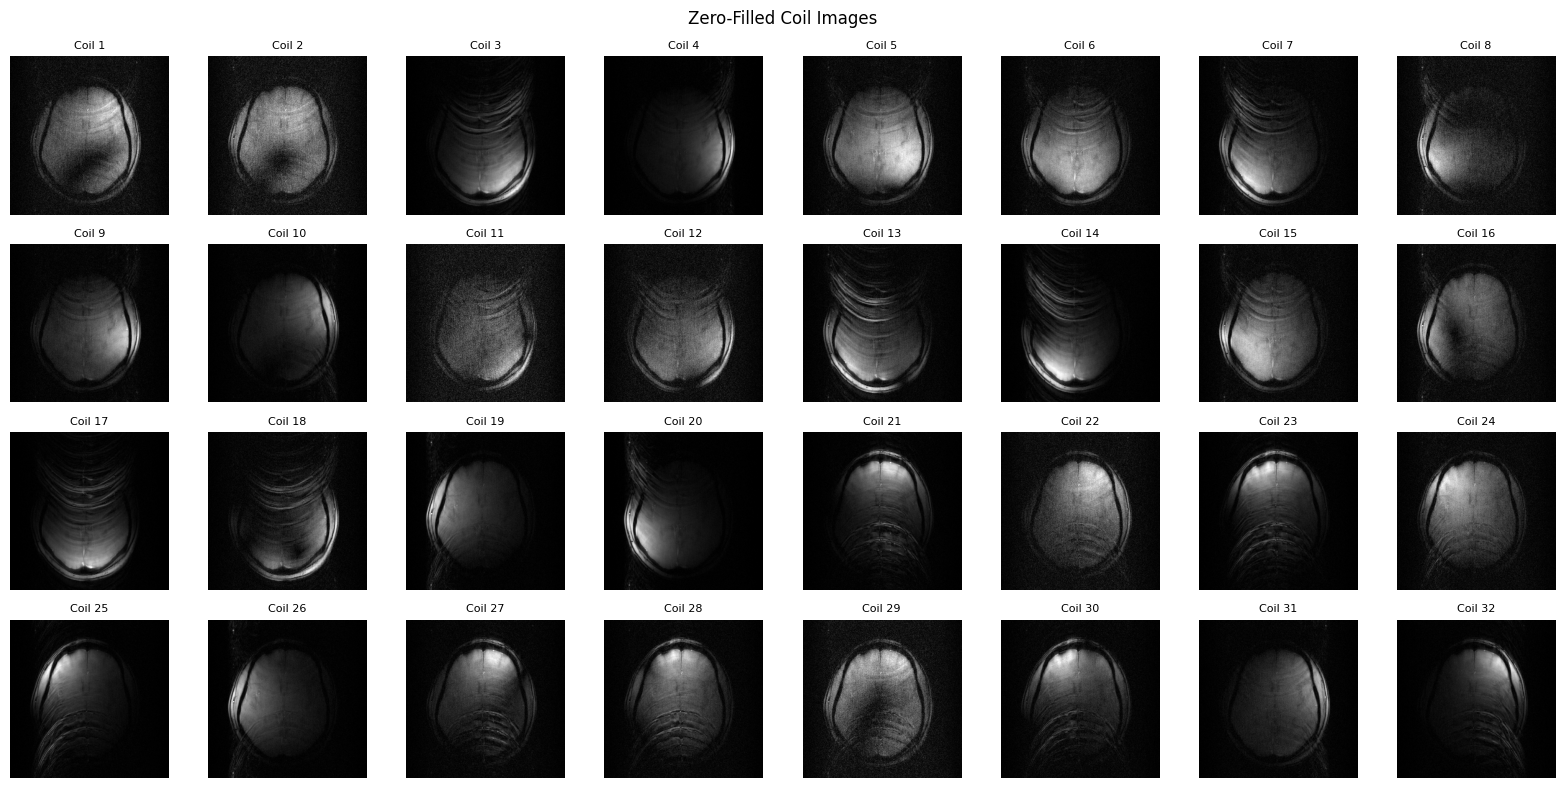

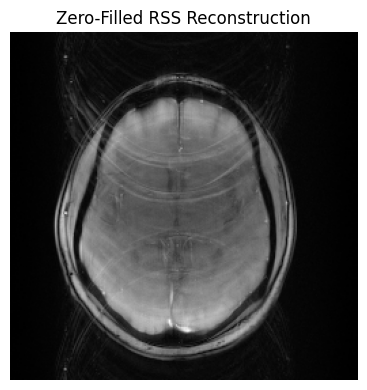

kspace_under: (32, 256, 256)
x_hat_zf_coils: (32, 256, 256)
x_hat_zf_rss: (256, 256)


In [15]:
# Zero-filled IFFT reconstruction

# Apply a centered 2D IFFT to each coil
x_hat_zf_coils = np.fft.fftshift(
    np.fft.ifft2(
        np.fft.ifftshift(kspace_under, axes=(-2, -1)),
        axes=(-2, -1)
    ),
    axes=(-2, -1)
)

# Combine the coil images using root-sum-of-squares
x_hat_zf_rss = np.sqrt(
    np.sum(np.abs(x_hat_zf_coils) ** 2, axis=0)
)

# Display all coil images
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for coil, ax in enumerate(axes.flat):
    if coil < x_hat_zf_coils.shape[0]:
        ax.imshow(np.abs(x_hat_zf_coils[coil]), cmap="gray")
        ax.set_title(f"Coil {coil + 1}", fontsize=8)
    ax.axis("off")

fig.suptitle("Zero-Filled Coil Images")
plt.tight_layout()
plt.show()

# Display the RSS reconstruction
plt.figure(figsize=(8, 4))
plt.imshow(x_hat_zf_rss, cmap="gray")
plt.title("Zero-Filled RSS Reconstruction")
plt.axis("off")
plt.tight_layout()
plt.show()

print("kspace_under:", kspace_under.shape)
print("x_hat_zf_coils:", x_hat_zf_coils.shape)
print("x_hat_zf_rss:", x_hat_zf_rss.shape)

## 5. SENSE Reconstruction

### 5.1 Coil-Sensitivity Estimation

Each receiver coil observes the same object with a different spatial sensitivity and phase.
SENSE uses these differences to separate signals that overlap after k-space undersampling.

Accurate coil-sensitivity maps are required for reliable SENSE unfolding (Pruessmann et al., 1999).
These maps can be estimated from a fully sampled reference acquisition.
The reference scan may have lower spatial resolution than the final image because coil sensitivities vary smoothly across space.

In this notebook, the sensitivity maps are estimated from the reference k-space using ESPIRiT.
ESPIRiT forms a calibration matrix from the fully sampled reference data and estimates complex coil-sensitivity maps from its eigenvectors.
Calibration-based sensitivity estimation is a critical part of parallel imaging (Çukur et al., 2026).

The estimated sensitivity maps have shape `[coil, y, x]`.
Their magnitudes describe how strongly each coil receives signal at each location.
Their phases describe the coil-dependent phase variation.

Sensitivity-map shape: (32, 256, 256)


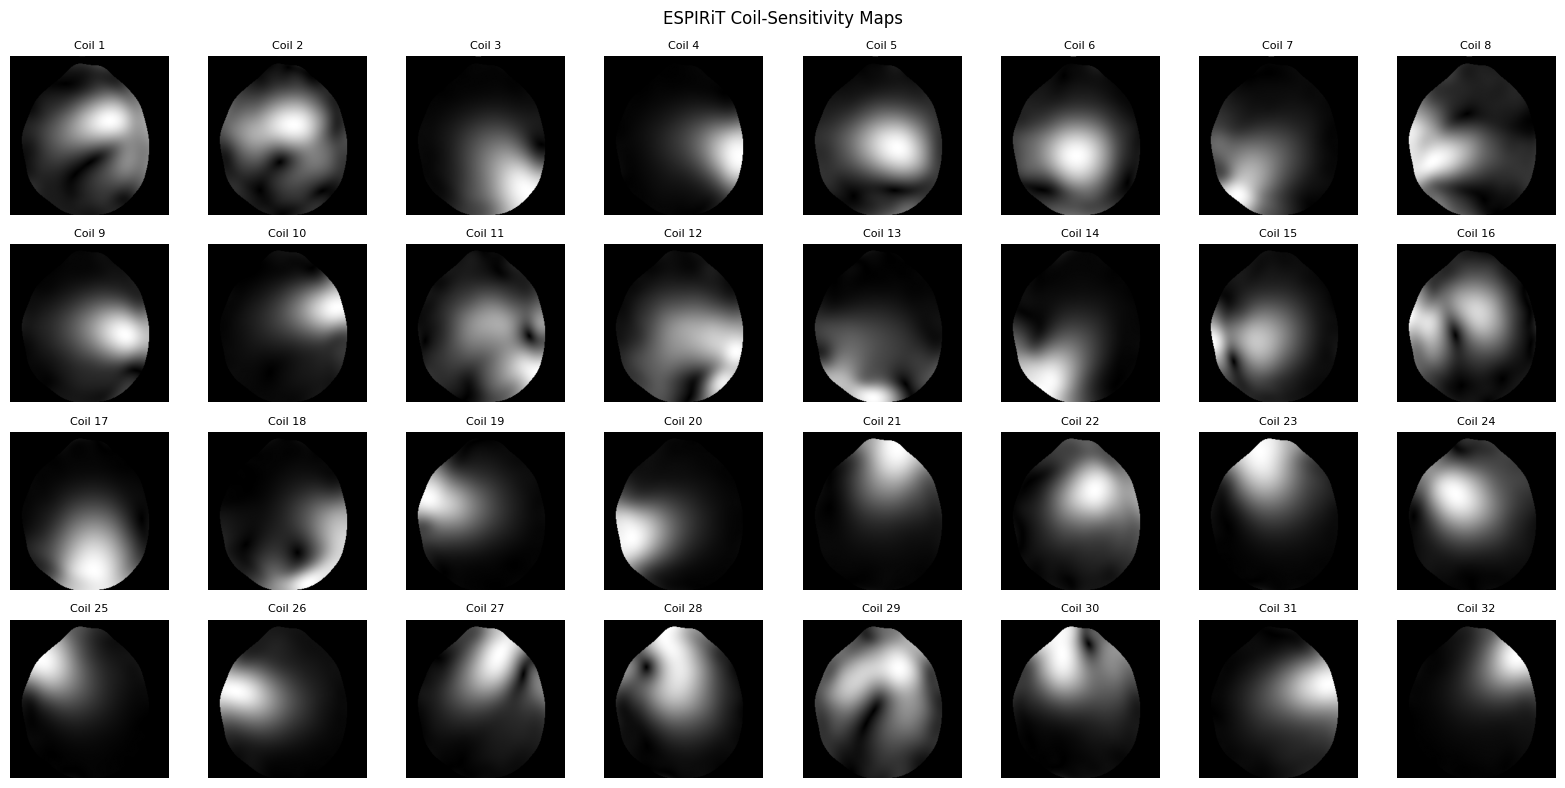

In [16]:
# Estimate coil-sensitivity maps using ESPIRiT

# If the reference scan contains only the acquired central ky lines,
# place them in the center of the full k-space grid
if kspace_ref.shape != kspace_under.shape:
    kspace_ref_full = np.zeros_like(kspace_under)

    n_ref = kspace_ref.shape[1]
    start = (kspace_under.shape[1] - n_ref) // 2

    kspace_ref_full[:, start:start + n_ref, :] = kspace_ref
else:
    kspace_ref_full = kspace_ref

# ESPIRiT coil-sensitivity estimation
sensitivity_maps = mr.app.EspiritCalib(
    kspace_ref_full,
    calib_width=24,
    crop=0.8,
    device=sp.Device(-1),
    show_pbar=False
).run()

print("Sensitivity-map shape:", sensitivity_maps.shape)

# Display the magnitude of all sensitivity maps
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

for coil, ax in enumerate(axes.flat):
    ax.imshow(np.abs(sensitivity_maps[coil]), cmap="gray")
    ax.set_title(f"Coil {coil + 1}", fontsize=8)
    ax.axis("off")

fig.suptitle("ESPIRiT Coil-Sensitivity Maps")
plt.tight_layout()
plt.show()

### 5.2 SENSE Reconstruction

Undersampling reduces the number of acquired points but causes multiple spatial locations to overlap in the zero-filled image.
SENSE separates these overlapping locations using the additional spatial encoding provided by the receiver-coil sensitivities.

For coil $c$, the forward model is

$$
y_c = M F(\hat{C}_c x) + n_c
$$

where $x$ is the unknown image, $\hat{C}_c$ is the estimated sensitivity map of coil $c$, $F$ is the 2D Fourier transform, $M$ is the sampling mask, $y_c$ is the acquired undersampled k-space, and $n_c$ is measurement noise.

#### Unregularized SENSE

The basic SENSE reconstruction finds the image whose predicted multi-coil k-space best matches the acquired data:

$$
\hat{x}_{\mathrm{SENSE}}
=
\underset{x}{\operatorname{argmin}}
\sum_c
\left\|
M F(\hat{C}_c x)-y_c
\right\|_2^2
$$

This data-consistency term requires the reconstructed image to agree with the measured k-space samples.
No additional image prior is used in the unregularized reconstruction.

#### Wavelet-Regularized Reconstruction

A wavelet sparsity prior can be added to reduce noise and residual undersampling artifacts:

$$
\hat{x}_{\mathrm{L1}}
=
\underset{x}{\operatorname{argmin}}
\sum_c
\left\|
M F(\hat{C}_c x)-y_c
\right\|_2^2
+
\lambda
\left\|
W x
\right\|_1
$$

Here, $W$ is the wavelet transform and $\lambda$ controls the strength of the regularization.
The $\ell_1$ norm encourages the wavelet representation of the reconstructed image to be sparse.
A larger $\lambda$ produces stronger artifact and noise suppression but may also remove fine image details.

The first reconstruction is conventional unregularized SENSE.
The second combines parallel imaging with compressed sensing and is often called a PICS reconstruction.

SenseRecon:   0%|          | 0/100 [00:00<?, ?it/s]

MaxEig:   0%|          | 0/30 [00:00<?, ?it/s]

L1WaveletRecon:   0%|          | 0/100 [00:00<?, ?it/s]

SENSE reconstruction shape: (256, 256)
L1 wavelet reconstruction shape: (256, 256)
SENSE relative error: 14.62%
L1 wavelet relative error: 13.49%


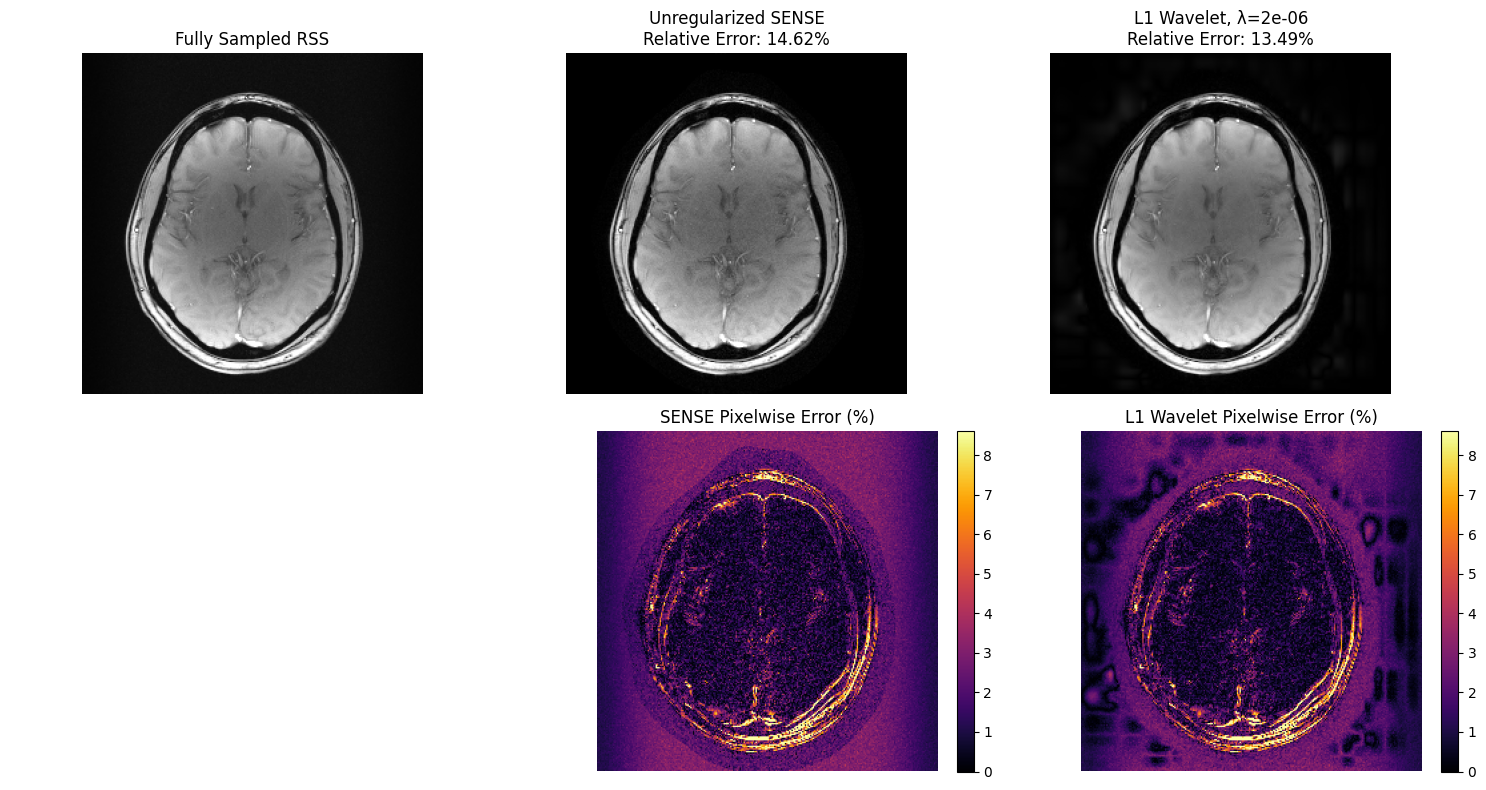

In [17]:
# Unregularized SENSE reconstruction

x_hat_sense = mr.app.SenseRecon(
    y=kspace_under,
    mps=sensitivity_maps,
    lamda=0,
    device=sp.Device(-1),
    show_pbar=True
).run()

# L1 wavelet-regularized reconstruction

lambda_wavelet = 2e-6

x_hat_l1_wavelet = mr.app.L1WaveletRecon(
    y=kspace_under,
    mps=sensitivity_maps,
    lamda=lambda_wavelet,
    device=sp.Device(-1),
    show_pbar=True
).run()

print("SENSE reconstruction shape:", x_hat_sense.shape)
print("L1 wavelet reconstruction shape:", x_hat_l1_wavelet.shape)

# Magnitude images

reference = np.abs(x_hat_rss)
sense = np.abs(x_hat_sense)
l1_wavelet = np.abs(x_hat_l1_wavelet)

# Match the global intensity scale to the fully sampled reference

sense *= np.sum(reference * sense) / (np.sum(sense ** 2) + 1e-12)
l1_wavelet *= np.sum(reference * l1_wavelet) / (
    np.sum(l1_wavelet ** 2) + 1e-12
)

# Total relative L2 error

relative_error_sense = (
    100
    * np.linalg.norm(sense - reference)
    / (np.linalg.norm(reference) + 1e-12)
)

relative_error_l1_wavelet = (
    100
    * np.linalg.norm(l1_wavelet - reference)
    / (np.linalg.norm(reference) + 1e-12)
)

print(f"SENSE relative error: {relative_error_sense:.2f}%")
print(f"L1 wavelet relative error: {relative_error_l1_wavelet:.2f}%")

# Pixelwise absolute error as a percentage of maximum reference intensity

error_sense = (
    100 * np.abs(sense - reference) / (np.max(reference) + 1e-12)
)

error_l1_wavelet = (
    100 * np.abs(l1_wavelet - reference) / (np.max(reference) + 1e-12)
)

# Use common display ranges

image_vmax = np.percentile(reference, 99.5)

error_vmax = max(
    np.percentile(error_sense, 99),
    np.percentile(error_l1_wavelet, 99)
)

# Display reconstructions and error maps

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(reference, cmap="gray", vmin=0, vmax=image_vmax)
axes[0, 0].set_title("Fully Sampled RSS")
axes[0, 0].axis("off")

axes[0, 1].imshow(sense, cmap="gray", vmin=0, vmax=image_vmax)
axes[0, 1].set_title(
    f"Unregularized SENSE\nRelative Error: {relative_error_sense:.2f}%"
)
axes[0, 1].axis("off")

axes[0, 2].imshow(l1_wavelet, cmap="gray", vmin=0, vmax=image_vmax)
axes[0, 2].set_title(
    f"L1 Wavelet, λ={lambda_wavelet:.0e}\n"
    f"Relative Error: {relative_error_l1_wavelet:.2f}%"
)
axes[0, 2].axis("off")

axes[1, 0].axis("off")

im1 = axes[1, 1].imshow(
    error_sense,
    cmap="inferno",
    vmin=0,
    vmax=error_vmax
)
axes[1, 1].set_title("SENSE Pixelwise Error (%)")
axes[1, 1].axis("off")
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 2].imshow(
    error_l1_wavelet,
    cmap="inferno",
    vmin=0,
    vmax=error_vmax
)
axes[1, 2].set_title("L1 Wavelet Pixelwise Error (%)")
axes[1, 2].axis("off")
fig.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 5.3 Wavelet Regularization Parameter Sweep

The L1-wavelet reconstruction depends on the regularization strength $\lambda$.
A small $\lambda$ leaves residual aliasing and noise, while a large $\lambda$ oversmooths the image and removes fine detail.

The sweep below starts at $\lambda = 0$, which reduces the problem to unregularized SENSE, and then covers a
logarithmically spaced range around the value $2\times10^{-6}$ used above.
Each reconstruction is scored inside the brain mask using relative error, PSNR, and SSIM, and the best value of
$\lambda$ is reported for each metric.

The sweep only records its own results and does not overwrite the reconstructions used in the following sections.

In [18]:
# Regularization values: zero plus a logarithmic range around 2e-6

lambda_sweep_values = np.concatenate((
    [0.0],
    np.logspace(-8, -4, 9)
))

print("탐색할 lambda 값:")

for value in lambda_sweep_values:
    print(f"  {value:.3e}")


sweep_relative_error = []
sweep_psnr = []
sweep_ssim = []
sweep_images = []

for value in lambda_sweep_values:

    if value == 0.0:
        x_sweep = mr.app.SenseRecon(
            y=kspace_under,
            mps=sensitivity_maps,
            lamda=0,
            device=sp.Device(-1),
            show_pbar=False
        ).run()
    else:
        x_sweep = mr.app.L1WaveletRecon(
            y=kspace_under,
            mps=sensitivity_maps,
            lamda=value,
            device=sp.Device(-1),
            show_pbar=False
        ).run()

    scores = evaluate_reconstruction(
        np.abs(x_sweep),
        reference_image,
        brain_mask
    )

    sweep_relative_error.append(scores["relative_error"])
    sweep_psnr.append(scores["psnr"])
    sweep_ssim.append(scores["ssim"])
    sweep_images.append(scores["image"])

    print(
        f"lambda = {value:.3e} | "
        f"오차 {scores['relative_error']:.2f}% | "
        f"PSNR {scores['psnr']:.2f} dB | "
        f"SSIM {scores['ssim']:.4f}"
    )


sweep_relative_error = np.asarray(sweep_relative_error)
sweep_psnr = np.asarray(sweep_psnr)
sweep_ssim = np.asarray(sweep_ssim)

탐색할 lambda 값:
  0.000e+00
  1.000e-08
  3.162e-08
  1.000e-07
  3.162e-07
  1.000e-06
  3.162e-06
  1.000e-05
  3.162e-05
  1.000e-04
lambda = 0.000e+00 | 오차 10.73% | PSNR 30.94 dB | SSIM 0.8955
lambda = 1.000e-08 | 오차 10.73% | PSNR 30.94 dB | SSIM 0.8957
lambda = 3.162e-08 | 오차 10.72% | PSNR 30.94 dB | SSIM 0.8962
lambda = 1.000e-07 | 오차 10.70% | PSNR 30.96 dB | SSIM 0.8976
lambda = 3.162e-07 | 오차 10.65% | PSNR 31.00 dB | SSIM 0.9017
lambda = 1.000e-06 | 오차 10.51% | PSNR 31.11 dB | SSIM 0.9112
lambda = 3.162e-06 | 오차 10.38% | PSNR 31.23 dB | SSIM 0.9208
lambda = 1.000e-05 | 오차 10.95% | PSNR 30.76 dB | SSIM 0.9009
lambda = 3.162e-05 | 오차 14.33% | PSNR 28.42 dB | SSIM 0.8501
lambda = 1.000e-04 | 오차 22.49% | PSNR 24.51 dB | SSIM 0.7687


상대오차 기준 최적 lambda: 3.162e-06 (10.38%)
PSNR 기준 최적 lambda: 3.162e-06 (31.23 dB)
SSIM 기준 최적 lambda: 3.162e-06 (0.9208)


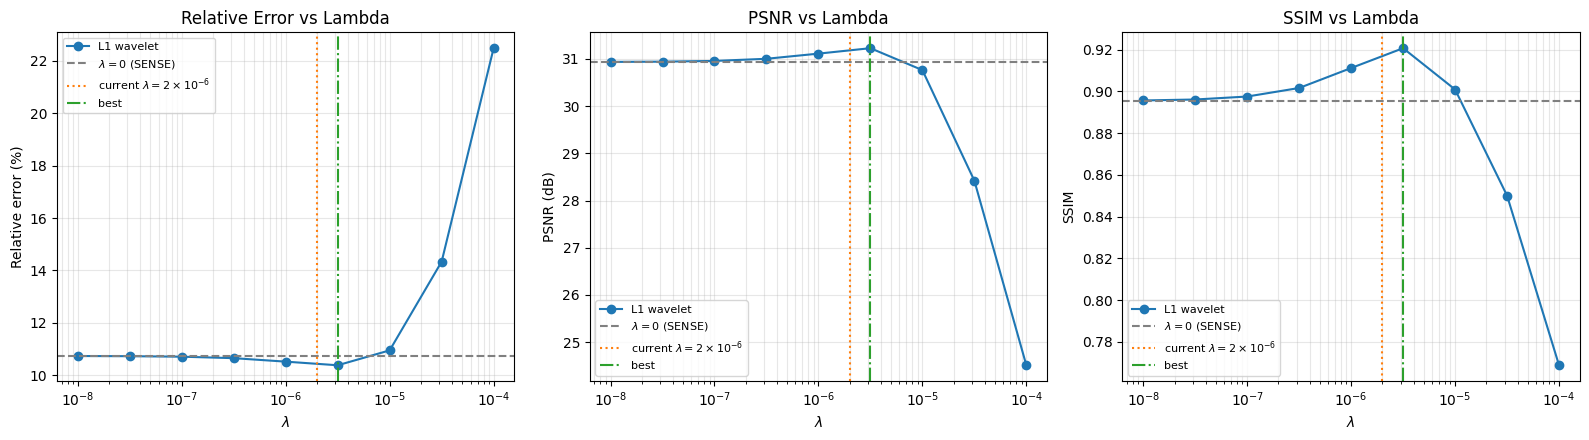

In [19]:
# Best lambda according to each metric

best_by_error = lambda_sweep_values[np.argmin(sweep_relative_error)]
best_by_psnr = lambda_sweep_values[np.argmax(sweep_psnr)]
best_by_ssim = lambda_sweep_values[np.argmax(sweep_ssim)]

print(
    f"상대오차 기준 최적 lambda: {best_by_error:.3e} "
    f"({np.min(sweep_relative_error):.2f}%)"
)

print(
    f"PSNR 기준 최적 lambda: {best_by_psnr:.3e} "
    f"({np.max(sweep_psnr):.2f} dB)"
)

print(
    f"SSIM 기준 최적 lambda: {best_by_ssim:.3e} "
    f"({np.max(sweep_ssim):.4f})"
)


# Plot each metric against lambda on a logarithmic axis

nonzero = lambda_sweep_values > 0

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

metric_settings = [
    (sweep_relative_error, "Relative error (%)", "Relative Error vs Lambda", best_by_error),
    (sweep_psnr, "PSNR (dB)", "PSNR vs Lambda", best_by_psnr),
    (sweep_ssim, "SSIM", "SSIM vs Lambda", best_by_ssim)
]

for ax, (values, ylabel, title, best_value) in zip(axes, metric_settings):

    ax.plot(
        lambda_sweep_values[nonzero],
        values[nonzero],
        marker="o",
        label="L1 wavelet"
    )

    ax.axhline(
        values[0],
        linestyle="--",
        color="gray",
        label=r"$\lambda=0$ (SENSE)"
    )

    ax.axvline(
        2e-6,
        linestyle=":",
        color="tab:orange",
        label=r"current $\lambda=2\times10^{-6}$"
    )

    ax.axvline(
        best_value,
        linestyle="-.",
        color="tab:green",
        label="best"
    )

    ax.set_xscale("log")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

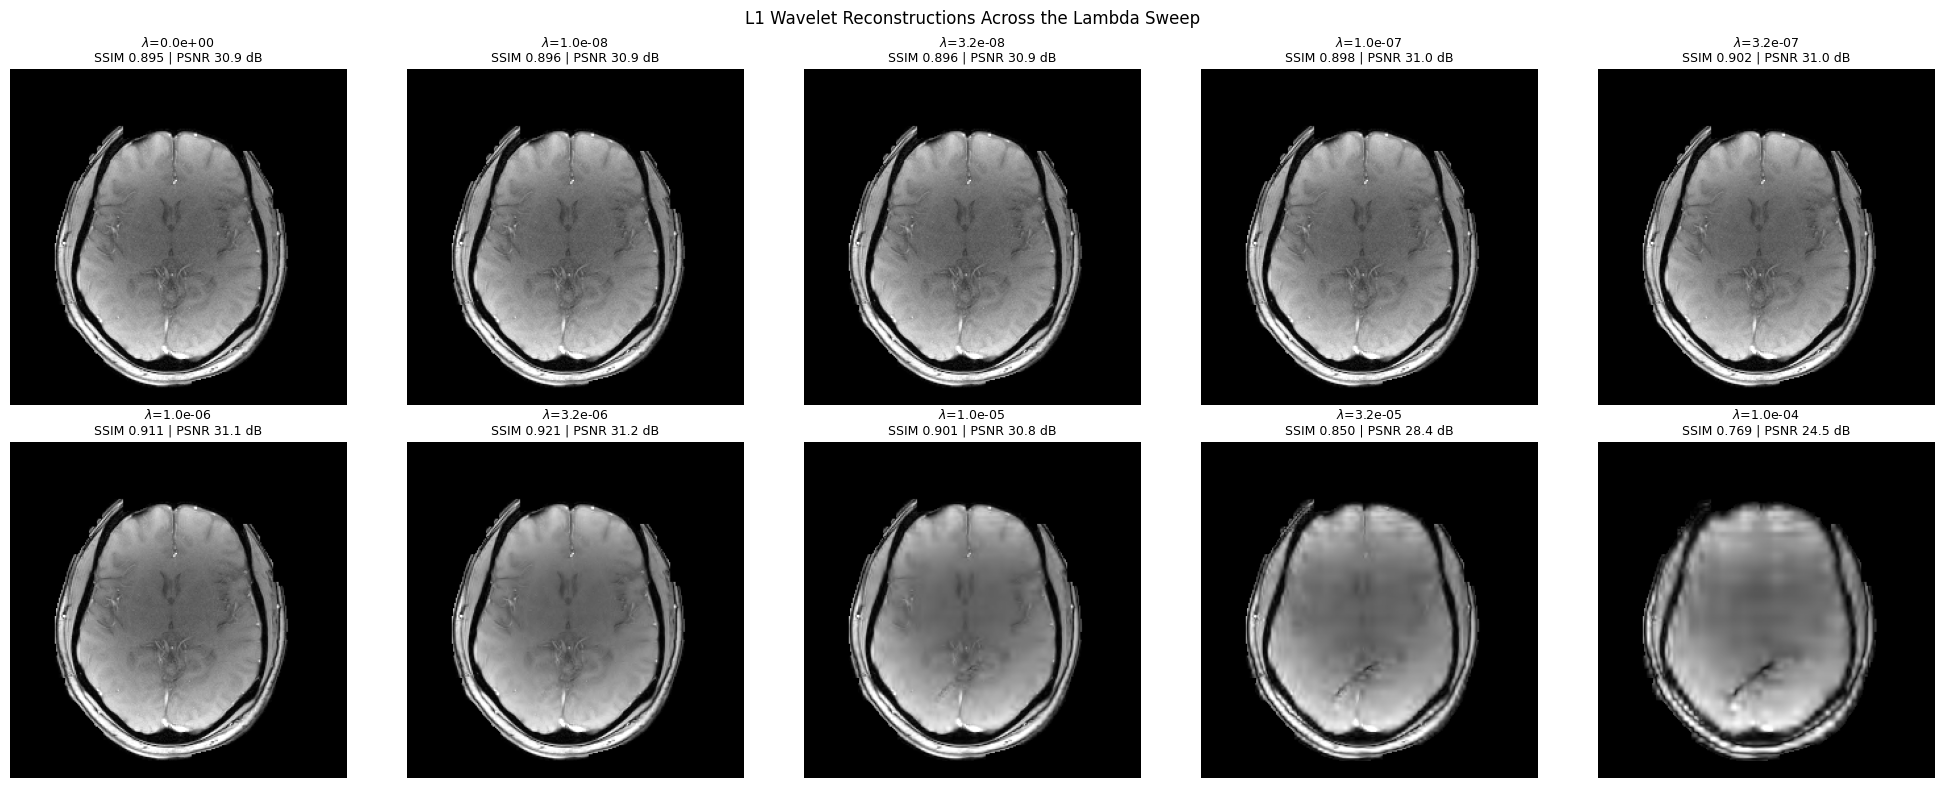

In [20]:
# Display the reconstruction obtained for each lambda

n_columns = 5
n_rows = int(np.ceil(len(lambda_sweep_values) / n_columns))

display_vmax = np.percentile(reference_image, 99.5)

fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(4 * n_columns, 4 * n_rows)
)

for index, ax in enumerate(axes.flat):

    if index < len(lambda_sweep_values):
        ax.imshow(
            sweep_images[index] * brain_mask,
            cmap="gray",
            vmin=0,
            vmax=display_vmax
        )

        ax.set_title(
            f"$\\lambda$={lambda_sweep_values[index]:.1e}\n"
            f"SSIM {sweep_ssim[index]:.3f} | "
            f"PSNR {sweep_psnr[index]:.1f} dB",
            fontsize=9
        )

    ax.axis("off")

fig.suptitle("L1 Wavelet Reconstructions Across the Lambda Sweep")
plt.tight_layout()
plt.show()

## 6. Self-Supervised AI Reconstruction

### 6.1 Self-Supervised K-Space Splitting

A supervised reconstruction network normally requires a fully sampled reference image during training.
In self-supervised reconstruction, the acquired undersampled data provide their own training target.

Let $\Omega$ denote all acquired k-space locations.
We divide these measured samples into two non-overlapping subsets:

$$
\Theta \cup \Lambda = \Omega,
\qquad
\Theta \cap \Lambda = \varnothing
$$

The samples in $\Theta$ are given to the reconstruction network as input.
The samples in $\Lambda$ are hidden from the input and used to calculate the training loss.

The corresponding k-space data are

$$
y_{\Theta}=M_{\Theta}y
$$

and

$$
y_{\Lambda}=M_{\Lambda}y
$$

where $M_{\Theta}$ and $M_{\Lambda}$ are the binary masks for the input and loss subsets.

The network predicts an image using only $y_{\Theta}$.
The predicted image is transformed back to multi-coil k-space and compared with the measured samples in $y_{\Lambda}$.

The fully sampled reconstruction is not used during training.
It is used only after training to evaluate the final AI reconstruction.

Total acquired samples: 32768
Input samples in Theta: 16384
Loss samples in Lambda: 16384
Protected central samples: 25


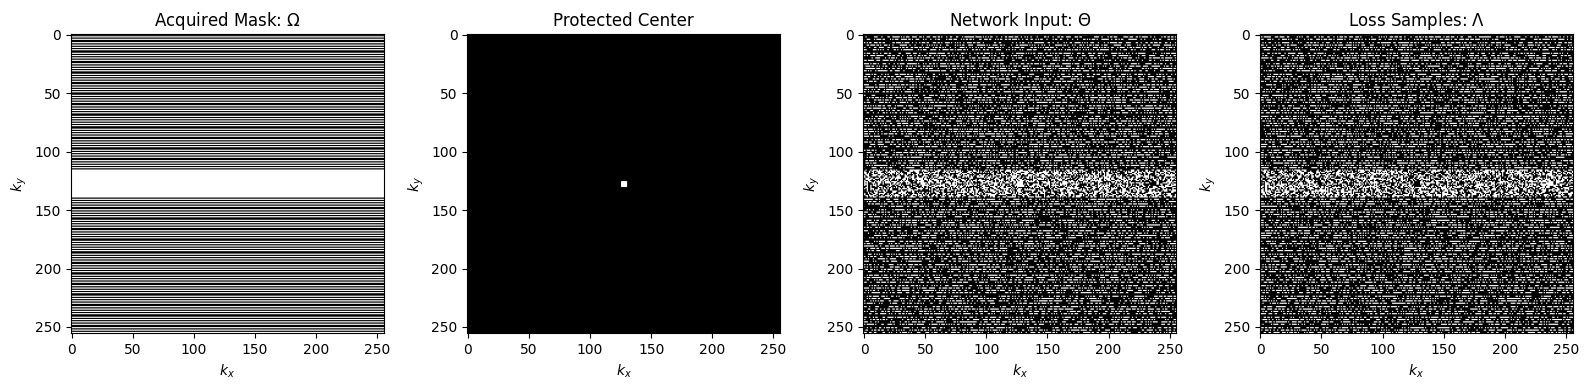

In [21]:
# Single-mask point-wise SSDU split with a protected central region

loss_fraction = 0.5
acs_size = 5
random_seed = 0

rng = np.random.default_rng(random_seed)

# All acquired k-space locations
acquired_mask = sampling_mask.astype(bool)

ny, nx = acquired_mask.shape
cy, cx = ny // 2, nx // 2

# Protect a small central region so it always remains in the input
acs_mask = np.zeros_like(acquired_mask)

y_start = cy - acs_size // 2
x_start = cx - acs_size // 2

acs_mask[
    y_start:y_start + acs_size,
    x_start:x_start + acs_size
] = True

# Only acquired points outside the protected region can be held out
candidate_mask = acquired_mask & ~acs_mask
candidate_indices = np.flatnonzero(candidate_mask)

# Select held-out samples for the self-supervised loss
n_loss_samples = int(loss_fraction * acquired_mask.sum())
n_loss_samples = min(n_loss_samples, candidate_indices.size)

loss_indices = rng.choice(
    candidate_indices,
    size=n_loss_samples,
    replace=False
)

# Lambda: held-out acquired samples used for the loss
mask_lambda = np.zeros_like(acquired_mask)
mask_lambda.flat[loss_indices] = True

# Theta: acquired samples used as network input
mask_theta = acquired_mask & ~mask_lambda

# Apply the masks to all receiver coils
kspace_theta = kspace_under * mask_theta[None, :, :]
kspace_lambda = kspace_under * mask_lambda[None, :, :]

# Check the split
assert not np.any(mask_theta & mask_lambda)
assert np.array_equal(mask_theta | mask_lambda, acquired_mask)

print("Total acquired samples:", acquired_mask.sum())
print("Input samples in Theta:", mask_theta.sum())
print("Loss samples in Lambda:", mask_lambda.sum())
print("Protected central samples:", np.sum(acquired_mask & acs_mask))

# Display the masks
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(acquired_mask, cmap="gray", aspect="auto")
axes[0].set_title(r"Acquired Mask: $\Omega$")

axes[1].imshow(acquired_mask & acs_mask, cmap="gray", aspect="auto")
axes[1].set_title("Protected Center")

axes[2].imshow(mask_theta, cmap="gray", aspect="auto")
axes[2].set_title(r"Network Input: $\Theta$")

axes[3].imshow(mask_lambda, cmap="gray", aspect="auto")
axes[3].set_title(r"Loss Samples: $\Lambda$")

for ax in axes:
    ax.set_xlabel("$k_x$")
    ax.set_ylabel("$k_y$")

plt.tight_layout()
plt.show()

### 6.2 MRI Forward and Adjoint Models

The reconstruction network predicts a single complex-valued image.
The MRI forward model converts this image into the multi-coil k-space that would be measured by the scanner.

For a sampling mask $M$, the forward model is

$$
A_M(x)_c
=
M F(\hat{C}_c x)
$$

where $x$ is the image, $\hat{C}_c$ is the estimated sensitivity map of coil $c$, and $F$ is the 2D Fourier transform.

The adjoint model transforms multi-coil k-space back into one coil-combined image:

$$
A_M^H(y)
=
\sum_c
\hat{C}_c^*
F^{-1}(M y_c)
$$

where $\hat{C}_c^*$ is the complex conjugate of the coil-sensitivity map.

The adjoint is not a complete inverse reconstruction.
It produces a zero-filled, sensitivity-combined image that can be used as the input to the neural network.

During training, $A_{\Theta}^H$ creates the network input from the samples in $\Theta$.
The forward model is later used to compare the predicted image with the held-out measurements in $\Lambda$.

PyTorch 버전: 2.12.0
MPS 빌드 여부: True
MPS 사용 가능: True
CUDA 사용 가능: False
선택된 장치: MPS (Apple GPU)
요청한 장치: mps
실제 텐서 장치: mps:0
GPU 사용 여부: True
CPU 행렬곱 평균 시간: 6.7 ms
MPS 행렬곱 평균 시간: 6.4 ms
속도 비율: 1.04배
Device: mps
K-space shape: torch.Size([32, 256, 256])
Sensitivity-map shape: torch.Size([32, 256, 256])
Number of acquired samples: 32768
Network-input shape: torch.Size([256, 256])
Training-input shape: torch.Size([256, 256])
Tensor device: mps:0


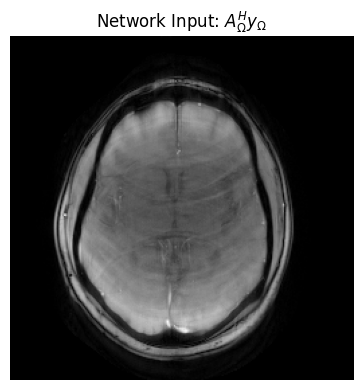

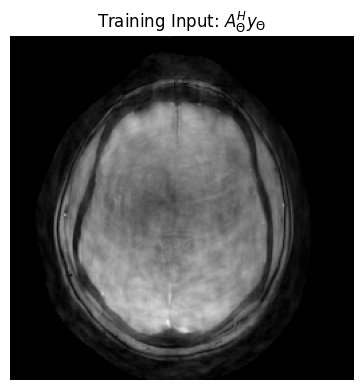

In [22]:
# Convert the MRI data to PyTorch tensors

device = select_device()

verify_device(device)

# Omega contains all acquired k-space locations
acquired_mask = sampling_mask.astype(bool)

kspace_torch = torch.tensor(
    kspace_under,
    dtype=torch.complex64,
    device=device
)

sensitivity_maps_torch = torch.tensor(
    sensitivity_maps,
    dtype=torch.complex64,
    device=device
)

acquired_mask_torch = torch.tensor(
    acquired_mask,
    dtype=torch.float32,
    device=device
)


# Theta and Lambda masks of the self-supervised split

mask_theta_torch = torch.tensor(
    mask_theta,
    dtype=torch.float32,
    device=device
)

mask_lambda_torch = torch.tensor(
    mask_lambda,
    dtype=torch.float32,
    device=device
)

print("Device:", device)
print("K-space shape:", kspace_torch.shape)
print("Sensitivity-map shape:", sensitivity_maps_torch.shape)
print("Number of acquired samples:", acquired_mask.sum())


# Centered 2D Fourier transform

def fft2c(image):
    return torch.fft.fftshift(
        torch.fft.fft2(
            torch.fft.ifftshift(
                image,
                dim=(-2, -1)
            ),
            dim=(-2, -1),
            norm="ortho"
        ),
        dim=(-2, -1)
    )


# Centered 2D inverse Fourier transform

def ifft2c(kspace):
    return torch.fft.fftshift(
        torch.fft.ifft2(
            torch.fft.ifftshift(
                kspace,
                dim=(-2, -1)
            ),
            dim=(-2, -1),
            norm="ortho"
        ),
        dim=(-2, -1)
    )


# MRI forward model: image to masked multi-coil k-space

def sense_forward(image, sensitivity_maps, mask):
    coil_images = sensitivity_maps * image[None, :, :]
    predicted_kspace = fft2c(coil_images)

    return predicted_kspace * mask[None, :, :]


# MRI adjoint model: masked multi-coil k-space to one image

def sense_adjoint(kspace, sensitivity_maps, mask):
    masked_kspace = kspace * mask[None, :, :]
    coil_images = ifft2c(masked_kspace)

    combined_image = torch.sum(
        torch.conj(sensitivity_maps) * coil_images,
        dim=0
    )

    return combined_image


# Create the network input using all acquired samples in Omega

x_omega = sense_adjoint(
    kspace_torch,
    sensitivity_maps_torch,
    acquired_mask_torch
)

print("Network-input shape:", x_omega.shape)


# Create the self-supervised training input using only the samples in Theta

x_theta = sense_adjoint(
    kspace_torch,
    sensitivity_maps_torch,
    mask_theta_torch
)

print("Training-input shape:", x_theta.shape)
print("Tensor device:", x_theta.device)


# Display the magnitude of the adjoint reconstruction

plt.figure(figsize=(8, 4))

plt.imshow(
    torch.abs(x_omega).detach().cpu().numpy(),
    cmap="gray"
)

plt.title(r"Network Input: $A_{\Omega}^{H}y_{\Omega}$")
plt.axis("off")
plt.tight_layout()
plt.show()


# Display the magnitude of the Theta-only adjoint reconstruction

plt.figure(figsize=(8, 4))

plt.imshow(
    torch.abs(x_theta).detach().cpu().numpy(),
    cmap="gray"
)

plt.title(r"Training Input: $A_{\Theta}^{H}y_{\Theta}$")
plt.axis("off")
plt.tight_layout()
plt.show()

### 6.3 Define a Small Residual CNN

The neural network receives the adjoint reconstruction $x_{\Theta}$ as a complex-valued image.
Because standard convolutional layers operate on real-valued arrays, the real and imaginary components are represented as two input channels.

The network predicts a residual correction to the input image:

$$
\hat{x}_{\phi}
=
x_{\Theta}
+
G_{\phi}(x_{\Theta})
$$

where $G_{\phi}$ is a convolutional neural network with trainable parameters $\phi$.

The residual connection allows the network to preserve information already present in the adjoint reconstruction while learning to reduce aliasing and other reconstruction errors.

This simplified network contains several convolutional layers with ReLU activation functions.
It represents the image-processing component of the reconstruction, while the MRI forward model will be used later to define the self-supervised k-space loss.

Network input shape: torch.Size([1, 2, 256, 256])
Network output shape: torch.Size([1, 2, 256, 256])
Predicted image shape: torch.Size([256, 256])
Trainable parameters: 47426


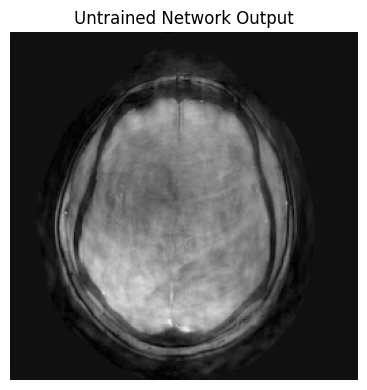

In [23]:
# Convert between complex images and two real-valued channels

def complex_to_channels(image):
    channels = torch.stack(
        [image.real, image.imag],
        dim=0
    )

    return channels.unsqueeze(0)


def channels_to_complex(channels):
    real = channels[0, 0]
    imag = channels[0, 1]

    return torch.complex(real, imag)


# Small image-domain residual CNN

class ResidualCNN(nn.Module):

    def __init__(self, n_features=32):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(
                in_channels=2,
                out_channels=n_features,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=n_features,
                out_channels=n_features,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                            in_channels=n_features,
                            out_channels=n_features,
                            kernel_size=3,
                            padding=1
                        ),
                        nn.ReLU(),

            nn.Conv2d(
                            in_channels=n_features,
                            out_channels=n_features,
                            kernel_size=3,
                            padding=1
                        ),
                        nn.ReLU(),

            nn.Conv2d(
                            in_channels=n_features,
                            out_channels=n_features,
                            kernel_size=3,
                            padding=1
                        ),
                        nn.ReLU(),

            nn.Conv2d(
                in_channels=n_features,
                out_channels=n_features,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                in_channels=n_features,
                out_channels=2,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, image):
        residual = self.cnn(image)

        return image + residual


# Create the network

model = ResidualCNN(
    n_features=32
).to(device)


# Normalize the all-data adjoint image

image_scale = torch.max(
    torch.abs(x_omega)
).detach()

x_theta_normalized = x_theta / (
    image_scale + 1e-8
)


# During training the network only sees the samples in Theta

network_input = complex_to_channels(
    x_theta_normalized
)


# Test one forward pass

network_output = model(
    network_input
)

x_test = (
    channels_to_complex(network_output)
    * image_scale
)


# Count trainable parameters

n_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Network input shape:", network_input.shape)
print("Network output shape:", network_output.shape)
print("Predicted image shape:", x_test.shape)
print("Trainable parameters:", n_parameters)


# Display the untrained network output

plt.figure(figsize=(8, 4))

plt.imshow(
    torch.abs(x_test).detach().cpu().numpy(),
    cmap="gray"
)

plt.title("Untrained Network Output")
plt.axis("off")
plt.tight_layout()
plt.show()

### 6.4 Self-Supervised Loss and Data Consistency

The CNN produces a complex-valued image prediction from the adjoint reconstruction.
Because the CNN is not guaranteed to preserve the acquired measurements, we apply a data-consistency update using the input samples in $\Theta$.

The predicted k-space at the input locations is

$$
\hat{y}_{\Theta}
=
A_{\Theta}(\hat{x})
$$

where $A_{\Theta}$ contains the coil sensitivities, Fourier transform, and input mask.

The data-consistency update is

$$
\hat{x}_{\mathrm{DC}}
=
\hat{x}
-
\alpha
A_{\Theta}^{H}
\left(
A_{\Theta}(\hat{x})-y_{\Theta}
\right)
$$

where $\alpha$ is the data-consistency step size.
This update moves the predicted image toward agreement with the acquired samples in $\Theta$.

The updated image is then transformed to the held-out k-space locations:

$$
\hat{y}_{\Lambda}
=
A_{\Lambda}(\hat{x}_{\mathrm{DC}})
$$

The self-supervised loss compares these predictions with the measured samples that were hidden from the network input:

$$
\mathcal{L}
=
\frac{
\left\|
\hat{y}_{\Lambda}-y_{\Lambda}
\right\|_2^2
}{
\left\|
y_{\Lambda}
\right\|_2^2+\epsilon
}
$$

The fully sampled image is not used in this loss.
The network is trained using only the acquired undersampled k-space.

Initial self-supervised loss on Lambda: 0.26301780343055725
Initial consistency on Theta: 0.06089886650443077


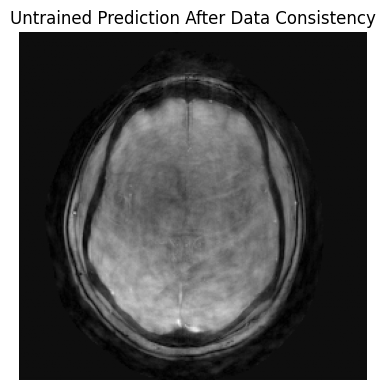

In [24]:
# Measured k-space at all acquired locations in Omega

y_omega = (
    kspace_torch
    * acquired_mask_torch[None, :, :]
)


# Measured k-space split into the input set Theta and the loss set Lambda

y_theta = (
    kspace_torch
    * mask_theta_torch[None, :, :]
)

y_lambda = (
    kspace_torch
    * mask_lambda_torch[None, :, :]
)


# One gradient-based data-consistency update

def data_consistency_update(
    image,
    step_size=0.5
):
    # Predict k-space at the input locations in Theta
    predicted_theta = sense_forward(
        image,
        sensitivity_maps_torch,
        mask_theta_torch
    )

    # Difference from the input measurements
    residual_theta = (
        predicted_theta
        - y_theta
    )

    # Transform the k-space residual back to image space
    gradient = sense_adjoint(
        residual_theta,
        sensitivity_maps_torch,
        mask_theta_torch
    )

    # Gradient-descent data-consistency update
    image_dc = (
        image
        - step_size * gradient
    )

    return image_dc


# Normalized self-supervised loss using only the held-out samples in Lambda

def data_consistency_loss(image):
    predicted_lambda = sense_forward(
        image,
        sensitivity_maps_torch,
        mask_lambda_torch
    )

    squared_error = torch.sum(
        torch.abs(
            predicted_lambda - y_lambda
        ) ** 2
    )

    measured_energy = torch.sum(
        torch.abs(y_lambda) ** 2
    )

    loss = squared_error / (
        measured_energy + 1e-12
    )

    return loss


# Consistency with the input samples in Theta, reported for monitoring only

def theta_consistency_loss(image):
    predicted_theta = sense_forward(
        image,
        sensitivity_maps_torch,
        mask_theta_torch
    )

    squared_error = torch.sum(
        torch.abs(
            predicted_theta - y_theta
        ) ** 2
    )

    measured_energy = torch.sum(
        torch.abs(y_theta) ** 2
    )

    return squared_error / (
        measured_energy + 1e-12
    )


# Test the complete forward pass before training

network_output = model(
    network_input
)

x_cnn = (
    channels_to_complex(network_output)
    * image_scale
)

x_prediction = data_consistency_update(
    x_cnn,
    step_size=0.5
)

initial_loss = data_consistency_loss(
    x_prediction
)

initial_theta_loss = theta_consistency_loss(
    x_prediction
)

print(
    "Initial self-supervised loss on Lambda:",
    initial_loss.item()
)

print(
    "Initial consistency on Theta:",
    initial_theta_loss.item()
)


# Display the untrained prediction after data consistency

plt.figure(figsize=(8, 4))

plt.imshow(
    torch.abs(x_prediction)
    .detach()
    .cpu()
    .numpy(),
    cmap="gray"
)

plt.title(
    "Untrained Prediction After Data Consistency"
)
plt.axis("off")
plt.tight_layout()
plt.show()

### 6.5 Train the Network

The network parameters are optimized using the held-out k-space loss.
At each epoch, the CNN predicts an image from the fixed adjoint reconstruction formed using $\Theta$.

A data-consistency update enforces agreement with the input measurements in $\Theta$.
The resulting image is then compared with the hidden measurements in $\Lambda$.

The Adam optimizer updates the CNN parameters to reduce this self-supervised loss.
The model with the lowest loss is retained for the final reconstruction.

Epoch 10000/10000
Total loss: 0.051399
Data-consistency loss: 0.050960
Wavelet loss: 0.438718
Best total loss: 0.051353


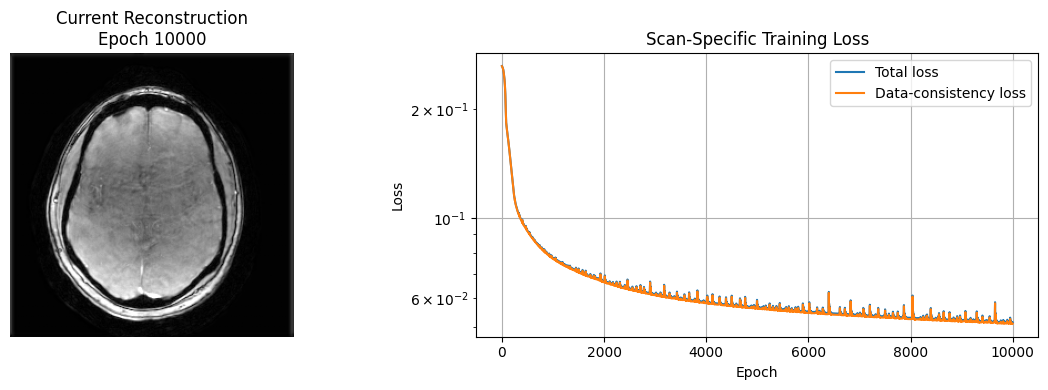

Best total loss: 0.051353
Best data-consistency loss: 0.050913


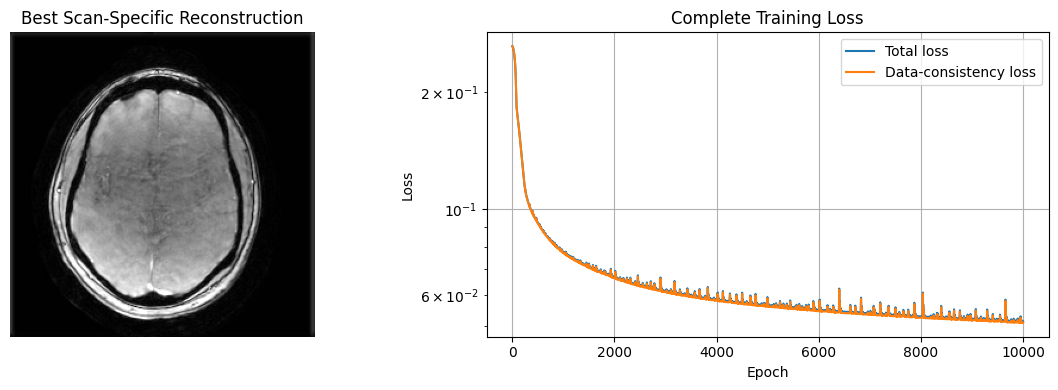

In [25]:
from IPython.display import clear_output


# Optional one-level Haar-wavelet L1 penalty

def wavelet_l1_loss(image):
    # Use an even image size for 2 x 2 Haar blocks
    ny = (image.shape[-2] // 2) * 2
    nx = (image.shape[-1] // 2) * 2
    image = image[:ny, :nx]

    a = image[0::2, 0::2]
    b = image[0::2, 1::2]
    c = image[1::2, 0::2]
    d = image[1::2, 1::2]

    # Haar detail coefficients
    horizontal = (a - b + c - d) / 2
    vertical = (a + b - c - d) / 2
    diagonal = (a - b - c + d) / 2

    detail_loss = (
        torch.mean(torch.abs(horizontal))
        + torch.mean(torch.abs(vertical))
        + torch.mean(torch.abs(diagonal))
    )

    # Normalize by the average image magnitude
    return detail_loss / (
        torch.mean(torch.abs(image)) + 1e-12
    )


# Train the scan-specific reconstruction network

n_epochs = 10000
learning_rate = 1e-4
dc_step_size = 0.5
beta_wavelet = 1e-3
display_every = 250

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

total_loss_history = []
data_loss_history = []

best_loss = np.inf
best_data_loss = np.inf
best_state = None

model.train()

for epoch in range(n_epochs):

    optimizer.zero_grad()

    # CNN prediction from the all-data adjoint reconstruction
    network_output = model(network_input)

    x_cnn = (
        channels_to_complex(network_output)
        * image_scale
    )

    # Enforce consistency with all acquired measurements
    x_prediction = data_consistency_update(
        x_cnn,
        step_size=dc_step_size
    )

    # Data-consistency loss on all acquired samples
    data_loss = data_consistency_loss(
        x_prediction
    )

    # Optional wavelet sparsity penalty
    wavelet_loss = wavelet_l1_loss(
        x_prediction
    )

    # Total training loss
    loss = (
        data_loss
        + beta_wavelet * wavelet_loss
    )

    current_loss = loss.item()
    current_data_loss = data_loss.item()
    current_wavelet_loss = wavelet_loss.item()

    total_loss_history.append(current_loss)
    data_loss_history.append(current_data_loss)

    # Save the parameters that produced the lowest total loss
    if current_loss < best_loss:
        best_loss = current_loss
        best_data_loss = current_data_loss

        best_state = {
            name: parameter.detach().cpu().clone()
            for name, parameter
            in model.state_dict().items()
        }

    loss.backward()
    optimizer.step()

    # Display the current image and loss
    if (epoch + 1) % display_every == 0:

        current_image = (
            torch.abs(x_prediction)
            .detach()
            .cpu()
            .numpy()
        )

        clear_output(wait=True)

        print(
            f"Epoch {epoch + 1}/{n_epochs}\n"
            f"Total loss: {current_loss:.6f}\n"
            f"Data-consistency loss: {current_data_loss:.6f}\n"
            f"Wavelet loss: {current_wavelet_loss:.6f}\n"
            f"Best total loss: {best_loss:.6f}"
        )

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 4)
        )

        axes[0].imshow(
            current_image,
            cmap="gray",
            vmin=0,
            vmax=np.percentile(
                current_image,
                99.5
            )
        )
        axes[0].set_title(
            f"Current Reconstruction\n"
            f"Epoch {epoch + 1}"
        )
        axes[0].axis("off")

        axes[1].plot(
            total_loss_history,
            label="Total loss"
        )
        axes[1].plot(
            data_loss_history,
            label="Data-consistency loss"
        )
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Loss")
        axes[1].set_title(
            "Scan-Specific Training Loss"
        )
        axes[1].set_yscale("log")
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout()
        plt.show()


# Restore the best network parameters

model.load_state_dict(best_state)
model.to(device)
model.eval()


# Generate the best reconstruction

with torch.no_grad():

    best_network_output = model(
        network_input
    )

    x_best_cnn = (
        channels_to_complex(
            best_network_output
        )
        * image_scale
    )

    x_best_prediction = data_consistency_update(
        x_best_cnn,
        step_size=dc_step_size
    )


x_hat_ai = (
    x_best_prediction
    .detach()
    .cpu()
    .numpy()
)

best_image = np.abs(x_hat_ai)

print(f"Best total loss: {best_loss:.6f}")
print(
    f"Best data-consistency loss: "
    f"{best_data_loss:.6f}"
)


# Display the best reconstruction and complete loss history

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].imshow(
    best_image,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(
        best_image,
        99.5
    )
)
axes[0].set_title(
    "Best Scan-Specific Reconstruction"
)
axes[0].axis("off")

axes[1].plot(
    total_loss_history,
    label="Total loss"
)
axes[1].plot(
    data_loss_history,
    label="Data-consistency loss"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Complete Training Loss")
axes[1].set_yscale("log")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.6 Final Reconstruction Using All Acquired Samples

During training, the network input was formed using only the samples in $\Theta$.
The measurements in $\Lambda$ were hidden from the input and used to calculate the self-supervised loss.

For the final reconstruction, all acquired samples in $\Omega$ are used:

$$
x_{\Omega}
=
A_{\Omega}^{H}y_{\Omega}
$$

The trained CNN processes this all-data adjoint reconstruction:

$$
\hat{x}_{\mathrm{CNN}}
=
x_{\Omega}
+
G_{\phi}(x_{\Omega})
$$

Data-consistency updates then enforce agreement with every acquired k-space sample:

$$
\hat{x}_{\mathrm{AI}}
=
\hat{x}_{\mathrm{CNN}}
-
\alpha A_{\Omega}^{H}
\left(
A_{\Omega}(\hat{x}_{\mathrm{CNN}})
-
y_{\Omega}
\right)
$$

Several data-consistency updates can be applied sequentially.
The fully sampled image remains outside the reconstruction and is used only to evaluate the final result.

Final AI reconstruction shape: (256, 256)
SENSE relative error: 14.62%
L1 wavelet relative error: 13.49%
Self-supervised AI relative error: 16.76%


/var/folders/ct/zv6yqb_d2q9735xm66wdls5h0000gn/T/ipykernel_3394/3285212460.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


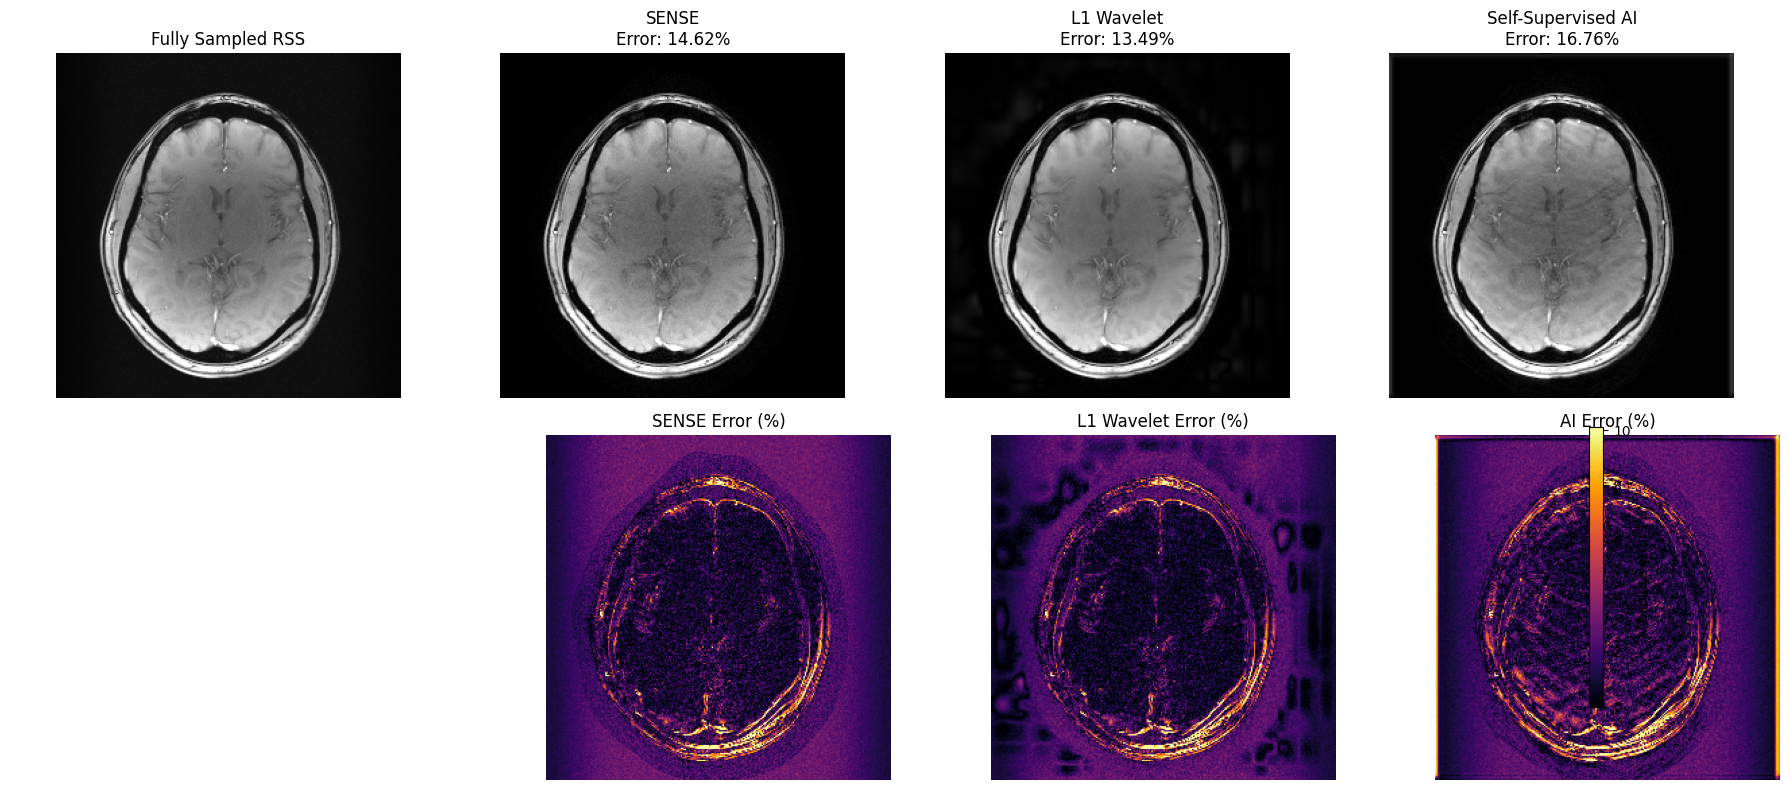

In [26]:
# Final AI reconstruction using all acquired k-space samples

def data_consistency_all(
    image,
    measured_kspace,
    mask,
    step_size=0.5
):
    predicted_kspace = sense_forward(
        image,
        sensitivity_maps_torch,
        mask
    )

    measured_kspace = (
        measured_kspace
        * mask[None, :, :]
    )

    residual = (
        predicted_kspace
        - measured_kspace
    )

    gradient = sense_adjoint(
        residual,
        sensitivity_maps_torch,
        mask
    )

    return image - step_size * gradient


# Form the adjoint reconstruction using all acquired samples

x_omega = sense_adjoint(
    kspace_torch,
    sensitivity_maps_torch,
    acquired_mask_torch
)

# Use the same normalization scale used during training

network_input_all = complex_to_channels(
    x_omega / (image_scale + 1e-8)
)


# Run the trained CNN and enforce full data consistency

n_dc_steps = 5

model.eval()

with torch.no_grad():

    network_output_all = model(
        network_input_all
    )

    x_ai = (
        channels_to_complex(
            network_output_all
        )
        * image_scale
    )

    for _ in range(n_dc_steps):
        x_ai = data_consistency_all(
            x_ai,
            kspace_torch,
            acquired_mask_torch,
            step_size=dc_step_size
        )


x_hat_ai = (
    x_ai
    .detach()
    .cpu()
    .numpy()
)

print(
    "Final AI reconstruction shape:",
    x_hat_ai.shape
)


# Magnitude images

reference = np.abs(x_hat_rss)
sense = np.abs(x_hat_sense)
l1_wavelet = np.abs(x_hat_l1_wavelet)
ai_reconstruction = np.abs(x_hat_ai)


# Match each reconstruction's global intensity scale to the reference

def match_intensity(image, reference):
    scale = (
        np.sum(reference * image)
        / (np.sum(image ** 2) + 1e-12)
    )

    return scale * image


sense = match_intensity(
    sense,
    reference
)

l1_wavelet = match_intensity(
    l1_wavelet,
    reference
)

ai_reconstruction = match_intensity(
    ai_reconstruction,
    reference
)


# Total relative L2 errors

def relative_error(image, reference):
    return (
        100
        * np.linalg.norm(image - reference)
        / (np.linalg.norm(reference) + 1e-12)
    )


error_total_sense = relative_error(
    sense,
    reference
)

error_total_l1 = relative_error(
    l1_wavelet,
    reference
)

error_total_ai = relative_error(
    ai_reconstruction,
    reference
)

print(
    f"SENSE relative error: "
    f"{error_total_sense:.2f}%"
)

print(
    f"L1 wavelet relative error: "
    f"{error_total_l1:.2f}%"
)

print(
    f"Self-supervised AI relative error: "
    f"{error_total_ai:.2f}%"
)


# Pixelwise errors as percentages of the maximum reference intensity

reference_max = np.max(reference) + 1e-12

error_map_sense = (
    100
    * np.abs(sense - reference)
    / reference_max
)

error_map_l1 = (
    100
    * np.abs(l1_wavelet - reference)
    / reference_max
)

error_map_ai = (
    100
    * np.abs(ai_reconstruction - reference)
    / reference_max
)


# Common display ranges

image_vmax = np.percentile(
    reference,
    99.5
)

error_vmax = max(
    np.percentile(error_map_sense, 99),
    np.percentile(error_map_l1, 99),
    np.percentile(error_map_ai, 99)
)


# Display reconstructions and error maps

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 8)
)

axes[0, 0].imshow(
    reference,
    cmap="gray",
    vmin=0,
    vmax=image_vmax
)
axes[0, 0].set_title(
    "Fully Sampled RSS"
)

axes[0, 1].imshow(
    sense,
    cmap="gray",
    vmin=0,
    vmax=image_vmax
)
axes[0, 1].set_title(
    f"SENSE\n"
    f"Error: {error_total_sense:.2f}%"
)

axes[0, 2].imshow(
    l1_wavelet,
    cmap="gray",
    vmin=0,
    vmax=image_vmax
)
axes[0, 2].set_title(
    f"L1 Wavelet\n"
    f"Error: {error_total_l1:.2f}%"
)

axes[0, 3].imshow(
    ai_reconstruction,
    cmap="gray",
    vmin=0,
    vmax=image_vmax
)
axes[0, 3].set_title(
    f"Self-Supervised AI\n"
    f"Error: {error_total_ai:.2f}%"
)

axes[1, 0].axis("off")

axes[1, 1].imshow(
    error_map_sense,
    cmap="inferno",
    vmin=0,
    vmax=error_vmax
)
axes[1, 1].set_title(
    "SENSE Error (%)"
)

axes[1, 2].imshow(
    error_map_l1,
    cmap="inferno",
    vmin=0,
    vmax=error_vmax
)
axes[1, 2].set_title(
    "L1 Wavelet Error (%)"
)

error_image = axes[1, 3].imshow(
    error_map_ai,
    cmap="inferno",
    vmin=0,
    vmax=error_vmax
)
axes[1, 3].set_title(
    "AI Error (%)"
)

for ax in axes.flat:
    ax.axis("off")

fig.colorbar(
    error_image,
    ax=axes[1, 1:],
    fraction=0.025,
    pad=0.02,
    label="Absolute error (%)"
)

plt.tight_layout()
plt.show()

### 6.7 Masked Comparison Using Three Metrics

The final comparison evaluates SENSE, L1-wavelet, and the self-supervised AI reconstruction inside the brain mask.
Excluding the surrounding air prevents the background noise from dominating the scores.

Each reconstruction is reported with relative $\ell_2$ error, PSNR, and SSIM, and the pixelwise error maps are
displayed over the masked region only.

In [27]:
# Evaluate every reconstruction inside the brain mask

evaluation = {
    "SENSE": evaluate_reconstruction(
        np.abs(x_hat_sense),
        reference_image,
        brain_mask
    ),
    "L1 Wavelet": evaluate_reconstruction(
        np.abs(x_hat_l1_wavelet),
        reference_image,
        brain_mask
    ),
    "Self-Supervised AI": evaluate_reconstruction(
        np.abs(x_hat_ai),
        reference_image,
        brain_mask
    )
}

print("뇌 영역 내부에서만 평가한 결과")

for name, scores in evaluation.items():
    print(
        f"{name}: "
        f"상대오차 {scores['relative_error']:.2f}% | "
        f"PSNR {scores['psnr']:.2f} dB | "
        f"SSIM {scores['ssim']:.4f}"
    )

뇌 영역 내부에서만 평가한 결과
SENSE: 상대오차 10.73% | PSNR 30.94 dB | SSIM 0.8955
L1 Wavelet: 상대오차 10.41% | PSNR 31.20 dB | SSIM 0.9185
Self-Supervised AI: 상대오차 12.23% | PSNR 29.80 dB | SSIM 0.8834


/var/folders/ct/zv6yqb_d2q9735xm66wdls5h0000gn/T/ipykernel_3394/89481669.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


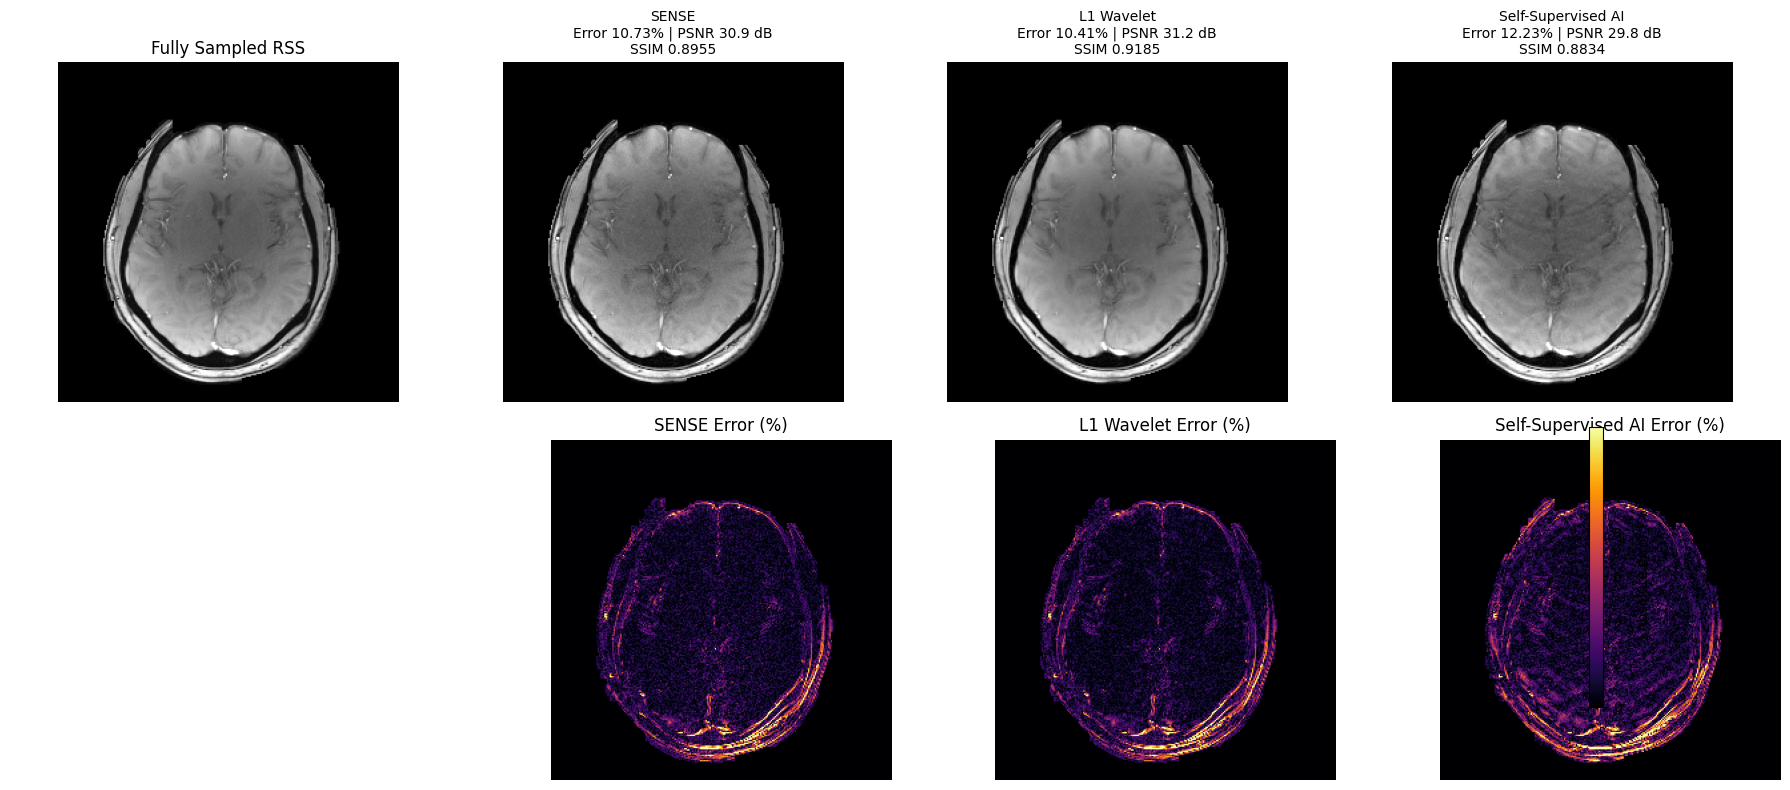

In [28]:
# Pixelwise error maps restricted to the brain mask

reference_peak = np.max(reference_image[brain_mask]) + 1e-12

error_maps = {
    name: (
        100
        * np.abs(scores["image"] - reference_image)
        / reference_peak
        * brain_mask
    )
    for name, scores in evaluation.items()
}

display_vmax = np.percentile(reference_image[brain_mask], 99.5)

error_vmax = max(
    np.percentile(error_map[brain_mask], 99)
    for error_map in error_maps.values()
)


# Display the masked reconstructions and their error maps

names = list(evaluation.keys())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes[0, 0].imshow(
    reference_image * brain_mask,
    cmap="gray",
    vmin=0,
    vmax=display_vmax
)
axes[0, 0].set_title("Fully Sampled RSS")

for column, name in enumerate(names, start=1):
    scores = evaluation[name]

    axes[0, column].imshow(
        scores["image"] * brain_mask,
        cmap="gray",
        vmin=0,
        vmax=display_vmax
    )

    axes[0, column].set_title(
        f"{name}\n"
        f"Error {scores['relative_error']:.2f}% | "
        f"PSNR {scores['psnr']:.1f} dB\n"
        f"SSIM {scores['ssim']:.4f}",
        fontsize=10
    )

axes[1, 0].axis("off")

for column, name in enumerate(names, start=1):
    error_image = axes[1, column].imshow(
        error_maps[name],
        cmap="inferno",
        vmin=0,
        vmax=error_vmax
    )

    axes[1, column].set_title(f"{name} Error (%)")

for ax in axes.flat:
    ax.axis("off")

fig.colorbar(
    error_image,
    ax=axes[1, 1:],
    fraction=0.025,
    pad=0.02,
    label="Absolute error (%)"
)

plt.tight_layout()
plt.show()

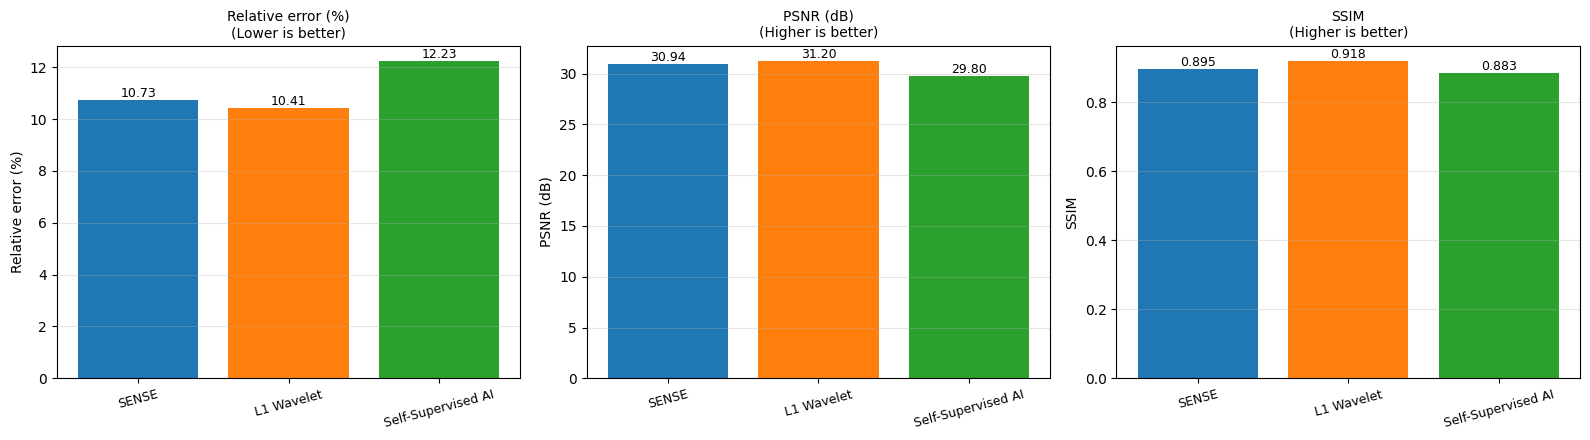

In [29]:
# Bar chart comparison of the three metrics

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

metric_keys = [
    ("relative_error", "Relative error (%)", "Lower is better"),
    ("psnr", "PSNR (dB)", "Higher is better"),
    ("ssim", "SSIM", "Higher is better")
]

positions = np.arange(len(names))

for ax, (key, ylabel, note) in zip(axes, metric_keys):
    values = [evaluation[name][key] for name in names]

    bars = ax.bar(positions, values, color=["tab:blue", "tab:orange", "tab:green"])

    ax.set_xticks(positions)
    ax.set_xticklabels(names, rotation=15, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n({note})", fontsize=10)
    ax.grid(True, axis="y", alpha=0.3)

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}" if key == "ssim" else f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()